In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
from scipy.io import wavfile
import os
import matplotlib.pyplot as plt

In [2]:
# SUBHARMONICS DURATION : SIGNAL DURATION RATIO
def subharmRatio(subharm_total_no : int, subharms, signal_duration):
    subharm_ratio = 0.
    subharm_per_second = 0.
    subharm_durations = []

    density_slope = 0.
    pct_subharm_num_second_half = 0.
    dur_density_slope = 0.
    pct_subharm_dur_second_half = 0.

    if subharm_total_no > 0:
        subharm_durations = [b - a for a, b in subharms]

        total_subharm_dur = sum(subharm_durations)
        subharm_ratio = total_subharm_dur/signal_duration
        subharm_per_second = subharm_total_no / signal_duration

        # Second half features
        half_time = signal_duration / 2.0
        n_second = sum(1 for (a, b) in subharms if a >= half_time)
        n_first = subharm_total_no - n_second

        pct_subharm_num_second_half = n_second/subharm_total_no
        density_slope = (n_second - n_first)/half_time

        subharm_dur_second = 0.0
        for a, b in subharms:
            subharm_dur_second += max(0.0, b - max(a, half_time))
        subharm_dur_first = total_subharm_dur - subharm_dur_second

        pct_subharm_dur_second_half = subharm_dur_second / total_subharm_dur
        dur_density_slope = (subharm_dur_second - subharm_dur_first)/half_time

    if subharm_ratio >= 1.0:
        raise ValueError("Subharmonic-signal ratio larger than 1.")

    return subharm_ratio, subharm_per_second, subharm_durations, density_slope, pct_subharm_num_second_half, dur_density_slope, pct_subharm_dur_second_half

# FIRST SUBHARMONIC OCCURENCE
def firstSubharmOccur(subharm_total_no, subharms, signal_duration):
    first_subharm_occur = signal_duration
    if subharm_total_no > 0:
        first_subharm_occur = subharms[0][0]
    
    return first_subharm_occur

# MEAN / MEDIAN / STD / CV SUBHARMONIC DURATION
def statsSubharmDur(subharm_total_no, subharm_durations):
    avg_subharm_dur, median_subharm_dur, std_subharm_dur, coeffOfVar_subharm_dur, longest_subharm_dur = 0., 0., np.nan, np.nan, 0.

    if subharm_total_no > 0:
        avg_subharm_dur = np.mean(subharm_durations)
        median_subharm_dur = np.median(subharm_durations)

        if subharm_total_no > 1: # at least 2 subharmonics for std calculation
            std_subharm_dur = np.std(subharm_durations, ddof=1)
            coeffOfVar_subharm_dur = std_subharm_dur / avg_subharm_dur

        longest_subharm_dur = np.max(subharm_durations)

    return avg_subharm_dur, median_subharm_dur, std_subharm_dur, coeffOfVar_subharm_dur, longest_subharm_dur


# INTER-SUBHARMONIC INTERVALS 
def interSubharmIntervals(subharm_total_no, subharms):

    mean_intervals, median_intervals, std_intervals, COV_intervals = np.nan, np.nan, np.nan, np.nan

    if subharm_total_no > 1: # at least 2 subharmonics for an interval
        inter_intervals = subharms[1:, 0] - subharms[:-1, 1]

        mean_intervals = np.mean(inter_intervals)
        median_intervals = np.median(inter_intervals)

        if subharm_total_no > 2: # at least 2 intervals for std calculation
            std_intervals = np.std(inter_intervals, ddof=1)
            COV_intervals = std_intervals / mean_intervals

    return mean_intervals, median_intervals, std_intervals, COV_intervals

In [3]:
# def interpolate_pitch(pitch):
#     pitch = pitch.copy()
#     pitch = np.array(pitch)
#     pitch[pitch <= 0] = np.nan
#     valid = np.isfinite(pitch) & (pitch > 0)

#     if np.sum(valid) < 2:
#         return pitch

#     pitch_interp = np.interp(
#         np.arange(len(pitch)),
#         np.where(valid)[0],
#         pitch[valid]
#     )

#     return pitch_interp

import numpy as np

def interpolate_short_nan_runs(pitch, time_step, max_nan_dur=0.15):
    
    pitch = np.asarray(pitch, dtype=float).copy()
    pitch[pitch <= 0] = np.nan

    n = len(pitch)
    is_nan = ~np.isfinite(pitch)

    if np.sum(~is_nan) < 2:
        return pitch

    max_nan_frames = int(np.floor(max_nan_dur / time_step))
    if max_nan_frames < 1:
        return pitch

    pitch_out = pitch.copy()

    i = 0
    while i < n:
        if not is_nan[i]:
            i += 1
            continue

        # start of NaN run
        start = i
        while i < n and is_nan[i]:
            i += 1
        end = i - 1

        run_len = end - start + 1

        # interpolate only short NaN runs that have valid neighbors on both sides
        left_idx = start - 1
        right_idx = end + 1

        left_ok = left_idx >= 0 and np.isfinite(pitch[left_idx])
        right_ok = right_idx < n and np.isfinite(pitch[right_idx])

        if run_len <= max_nan_frames and left_ok and right_ok:
            x_known = np.array([left_idx, right_idx])
            y_known = np.array([pitch[left_idx], pitch[right_idx]])
            x_fill = np.arange(start, end + 1)

            pitch_out[x_fill] = np.interp(x_fill, x_known, y_known)

    return pitch_out

def getFrameXt(pitch, frame_idx, n_side, fref_mode, min_valid_frames=10): # maybe test win_len: 100 ms, 150 ms, 200 ms, 300 ms

    win_start = frame_idx-n_side
    win_end = frame_idx+n_side
    window_pitch = pitch[win_start:win_end+1]

    local_frame_idx = n_side
    frame_pitch = window_pitch[local_frame_idx]
    if not np.isfinite(frame_pitch) or frame_pitch <= 0:
        return np.nan
    
    left = local_frame_idx
    step_count = 0
    while left-1 >= 0 and step_count < n_side:
        candidate = window_pitch[left-1]
        if not np.isfinite(candidate) or candidate <= 0:
            break

        left -= 1
        step_count += 1

    right = local_frame_idx
    step_count = 0
    while right+1 < len(window_pitch) and step_count < n_side:
        candidate = window_pitch[right+1]
        if not np.isfinite(candidate) or candidate <= 0:
            break

        right += 1
        step_count += 1

    window_pitch_valid = window_pitch[left:right+1]

    if len(window_pitch_valid) < min_valid_frames:#((n_side // 10) * 10):
        return np.nan
    
    if fref_mode == "upper_60_80_median":
        p60 = np.percentile(window_pitch_valid, 60)
        p80 = np.percentile(window_pitch_valid, 80)
        fref = np.median(window_pitch_valid[(window_pitch_valid >= p60) & (window_pitch_valid <= p80)])
    elif fref_mode == "upper_70_90_median":
        p70 = np.percentile(window_pitch_valid, 70)
        p90 = np.percentile(window_pitch_valid, 90)
        fref = np.median(window_pitch_valid[(window_pitch_valid >= p70) & (window_pitch_valid <= p90)])
    elif fref_mode == "upper_80_90_median":
        p80 = np.percentile(window_pitch_valid, 80)
        p90 = np.percentile(window_pitch_valid, 90)
        fref = np.median(window_pitch_valid[(window_pitch_valid >= p80) & (window_pitch_valid <= p90)])
    elif fref_mode == "median": # median
        fref = np.median(window_pitch_valid)
    else:
        raise ValueError("Unsupported fref_mode")
    
    # print(f"f_ref = {fref}")
    if not np.isfinite(fref) or fref <= 0:
        return np.nan
    x_frame = np.log2(window_pitch[local_frame_idx]/fref)
    # print(np.log2(window_pitch/fref))
    # print(x_frame)
    return x_frame


def getXtFrames(pitch, first_frame_idx, last_frame_idx, n_side, fref_mode):
    x_frames = []
    # c = 0
    for frame_idx in range(first_frame_idx, last_frame_idx+1):
        x_t = getFrameXt(pitch, frame_idx, n_side, fref_mode)
        # if np.isnan(x_t):
            # c += 1
        x_frames.append(x_t)
    
    # print(c)
    valid_mask = np.isfinite(x_frames)
    # print(np.sum(valid_mask == False))
    return np.array(x_frames)

In [4]:
def gaussian_pdf(x, mu, sigma):
    sigma = max(float(sigma), 1e-6)
    return (1.0 / (np.sqrt(2.0 * np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def em_two_fixed_means(x_frames, prior_non_init, prior_sub_init, max_iter=200, tol=1e-4, sigma_floor=0.05,
                       mu_non=0.0, mu_sub=-1.0, sigma_non_init=0.15, sigma_sub_init=0.15,
                       ):
    
    x = np.asarray(x_frames, dtype=float)
    x = x[np.isfinite(x)]

    if x.size < 5:
        # raise ValueError("Not enough valid x_t samples for EM.")
        return None

    prior_non = float(prior_non_init)
    prior_sub = float(prior_sub_init)
    sigma_non = max(float(sigma_non_init), sigma_floor)
    sigma_sub = max(float(sigma_sub_init), sigma_floor)

    prev_posterior_sub = None

    for i in range(max_iter):
        # print(f"ITERATION {i+1}")

        # E-step
        p_non = prior_non * gaussian_pdf(x, mu_non, sigma_non)
        p_sub = prior_sub * gaussian_pdf(x, mu_sub, sigma_sub)
      
        posterior_non = p_non / (p_non + p_sub + 1e-12)
        posterior_sub = p_sub / (p_non + p_sub + 1e-12)

        # convergence check right after E-step
        if prev_posterior_sub is not None:
            max_posterior_change = np.max(np.abs(posterior_sub - prev_posterior_sub))
            # print(f"max posterior change = {max_posterior_change:.5f}")

            if max_posterior_change < tol:
                # print(f"Stopping: max posterior change = {max_posterior_change:.5f}")
                break
        
        prev_posterior_sub = posterior_sub.copy()

        # M-step
        N_non = np.sum(posterior_non)
        N_sub = np.sum(posterior_sub)
        
        prior_non = N_non / x.size
        prior_sub = N_sub / x.size

        sigma_non = np.sqrt(np.sum(posterior_non * (x - mu_non) ** 2) / (N_non + 1e-12))
        sigma_non = max(float(sigma_non), sigma_floor)

        sigma_sub = np.sqrt(np.sum(posterior_sub * (x - mu_sub) ** 2) / (N_sub + 1e-12))
        sigma_sub = max(float(sigma_sub), sigma_floor)

        # print(
        #     f"prior_non={prior_non:.3f}, prior_sub={prior_sub:.3f}, "
        #     f"sigma_non={sigma_non:.4f}, sigma_sub={sigma_sub:.4f}"
        # )


    # final E-step with final parameters
    p_non = prior_non * gaussian_pdf(x, mu_non, sigma_non)
    p_sub = prior_sub * gaussian_pdf(x, mu_sub, sigma_sub)

    posterior_non = p_non / (p_non + p_sub + 1e-12)
    posterior_sub = p_sub / (p_non + p_sub + 1e-12)

    return {
        "prior_non": prior_non,
        "prior_sub": prior_sub,
        "mu_non": mu_non,
        "mu_sub": mu_sub,
        "sigma_non": sigma_non,
        "sigma_sub": sigma_sub,
        "posterior_non": posterior_non,
        "posterior_sub": posterior_sub,
    }

def smooth_posterior(posterior, win_len):
    """
    Simple moving average smoothing.
    win_len should usually be odd: 3, 5, 7...
    """
    posterior = np.asarray(posterior, dtype=float)

    if win_len <= 1:
        return posterior.copy()

    kernel = np.ones(win_len, dtype=float) / win_len
    posterior_smooth = np.convolve(posterior, kernel, mode="same")
    return posterior_smooth

In [5]:
def find_runs(labels):
    labels = np.asarray(labels, dtype=bool)
    runs = []

    if len(labels) == 0:
        return runs

    start = 0
    current = labels[0]

    for i in range(1, len(labels)):
        if labels[i] != current:
            runs.append((current, start, i - 1))
            start = i
            current = labels[i]

    runs.append((current, start, len(labels) - 1))
    return runs

def fill_short_gaps(labels, min_gap_frames):
    """
    If a zero-run between two positive runs is short enough,
    convert it to ones.
    """
    labels = np.asarray(labels, dtype=bool).copy()
    runs = find_runs(labels)

    for value, start, end in runs:
        run_len = end - start + 1

        if value == False and run_len <= min_gap_frames:
            left_is_sub = start > 0 and labels[start - 1]
            right_is_sub = end < len(labels) - 1 and labels[end + 1]

            if left_is_sub and right_is_sub:
                labels[start:end + 1] = True

    return labels

def remove_short_subharmonic_runs(labels, min_len_frames):
    """
    Remove positive runs that are shorter than min_len_frames.
    """
    labels = np.asarray(labels, dtype=bool).copy()
    runs = find_runs(labels)

    for value, start, end in runs:
        run_len = end - start + 1

        if value == True and run_len < min_len_frames:
            labels[start:end + 1] = False

    return labels

def labels_to_intervals(times, labels):
    intervals = []
    in_interval = False
    start_idx = None

    for i, lab in enumerate(labels):
        # Start of subharmonic interval reached
        if lab == True and in_interval == False:
            in_interval = True
            start_idx = i

        # End of subharmonic interval reached
        elif lab == False and in_interval == True:
            end_idx = i - 1
            intervals.append((times[start_idx], times[end_idx]))
            in_interval = False

    # Subharmonic till the end
    if in_interval:
        intervals.append((times[start_idx], times[len(labels) - 1]))

    return intervals

In [6]:
# TODO: WINDOW HAS TO BE ONLY VALUES FOR A VALID X_T ?
# TODO: MAYBE SMOOTH MORE THE POSTERIORS ?

def detectSubharmonics(data, tmin_cutoff, win_len, fref_mode, min_gap_dur, min_subharm_dur):

    # PREPARE DATA
    times = data[:, 0]
    pitch = data[:, 1]
    time_step = np.round(np.median(np.diff(times)), 4)
    pitch_preprocessed = interpolate_short_nan_runs(pitch, time_step, max_nan_dur=0.2)

    if len(times) != len(pitch_preprocessed):
        raise IndexError("Time indeces don't match pitch values!")

    n_side = int(round((win_len / 2) / time_step))
    # first_frame_idx = n_side # frame_idx = np.searchsorted(times, times[0] + win_len/2)
    # last_frame_idx = len(pitch_preprocessed) - n_side -1
    sample_length = times[-1]
    first_frame_idx = max(n_side, np.searchsorted(times, tmin_cutoff, side='left')) # frame_idx = np.searchsorted(times, times[0] + win_len/2)
    last_frame_idx = min(len(times) - n_side -1, np.searchsorted(times, sample_length-tmin_cutoff, side='right') - 1)
    
    # GET X_T FEATURES
    x_frames = getXtFrames(pitch_preprocessed, first_frame_idx, last_frame_idx, n_side, fref_mode)
    time_frames = times[first_frame_idx:last_frame_idx+1]
    valid_mask = np.isfinite(x_frames)

    # CLUSTER WITH EM ALGORITHM
    prior_non_init, prior_sub_init = 0.9, 0.1
    em = em_two_fixed_means(x_frames[valid_mask], prior_non_init, prior_sub_init)   
    if em is None:
        return [], sample_length
    
    posterior_sub_full = np.zeros(len(x_frames), dtype=float)
    posterior_sub_valid = em["posterior_sub"]
    posterior_sub_full[valid_mask] = posterior_sub_valid

    # SMOOTH POSTERIORS
    smooth_span_sec = 0.05
    smooth_win_len = int(round(smooth_span_sec / time_step))
    if smooth_win_len % 2 == 0:
        smooth_win_len += 1
    smooth_win_len = max(smooth_win_len, 1)

    posterior_smoothed = smooth_posterior(posterior_sub_full, smooth_win_len)

    # PREDICT FRAMES
    decision_thresh = 0.5
    frame_preds_smoothed = (posterior_smoothed >= decision_thresh)
    # print(frame_preds_smoothed.sum())


    # POST PROCCESS FRAMES TO INTERVALS
    min_len_frames = int(np.ceil(min_subharm_dur / time_step))
    min_gap_frames = int(np.floor(min_gap_dur / time_step))

    frame_preds = fill_short_gaps(frame_preds_smoothed, min_gap_frames)
    frame_preds = remove_short_subharmonic_runs(frame_preds_smoothed, min_len_frames)
    frame_preds = fill_short_gaps(frame_preds_smoothed, min_gap_frames)

    intervals = labels_to_intervals(time_frames, frame_preds)

    return intervals, sample_length

In [7]:
# RUN ALGORITHM -> GET SUBHARMONIC INTERVALS [(a, b), (c, d), ...] -> SAVE TO DICT
groups = ["HC", "RBD", "PN", "MSA"]

t_cutoff = 1.0
win_len = 0.25
fref_mode= "upper_70_90_median"
min_gap=0.5
min_subharm_len=0.05

result_rows_monolog = []
result_rows_zahradnik = []
result_rows_overall = []

# MONOLOG
for group in groups:

    folder_path = Path(f"praat_pitches/monolog/{group}")

    if folder_path.exists():
        for file_path in folder_path.iterdir():
            if file_path.is_file() and file_path.suffix.lower() == ".txt":
                
                data = np.loadtxt(file_path, delimiter="\t")
                sample_name = file_path.stem.replace("Pitch ", "")

                
                
                subharms, sample_duration = detectSubharmonics(data, t_cutoff, win_len, fref_mode, min_gap, min_subharm_len)
                subharms = np.asarray(subharms, dtype=float)

                # print(sample_name)
                # print(sample_duration)
                # print(subharms)
                # for subharm in subharms:
                #     print(f"{subharm[0]:.3f} {subharm[1]:.3f}")

                # ABSOLUTE NUMBER OF SUBHARMONICS IN THE SIGNAL
                subharm_total_no = len(subharms)
                # print(f"TOTAL NO. OF SUBHARMONICS: {subharm_total_no}")

                # SUBHARMONICS DURATION : SIGNAL DURATION RATIO
                subharm_ratio, subharm_per_second, subharm_durations, density_slope, pct_subharm_num_second_half, dur_density_slope, pct_subharm_dur_second_half = subharmRatio(subharm_total_no, subharms, sample_duration)
                # print(f"SUBHARMONICS-SIGNAL RATIO: {subharm_ratio}")

                subharm_durations = np.asarray(subharm_durations, dtype=float)

                # FIRST SUBHARMONIC OCCURENCE
                first_subharm_occur = firstSubharmOccur(subharm_total_no, subharms, sample_duration)
                # print(f"SUBHARMONIC FIRST OCCURENCE: {first_subharm_occur} seconds")

                # SUBHARMONIC DURATION STATS
                avg_subharm_dur, median_subharm_dur, std_subharm_dur, coeffOfVar_subharm_dur, longest_subharm_dur = statsSubharmDur(subharm_total_no, subharm_durations)
                # print(f"AVERAGE SUBHARMONIC DURATION: {avg_subharm_dur} seconds")    

                # INTER-SUBHARMONIC INTERVALS      
                mean_intervals, median_intervals, std_intervals, COV_intervals = interSubharmIntervals(subharm_total_no, subharms)
                # print(mean_intervals, median_intervals, std_intervals, COV_intervals)

                result_rows_monolog.append(
                    (sample_name, group,
                    subharm_total_no, 
                    subharm_ratio, subharm_per_second,
                    density_slope, pct_subharm_num_second_half, dur_density_slope, pct_subharm_dur_second_half,
                    first_subharm_occur, 
                    avg_subharm_dur, median_subharm_dur, std_subharm_dur, coeffOfVar_subharm_dur, longest_subharm_dur,
                    mean_intervals, median_intervals, std_intervals, COV_intervals))
                
                result_rows_overall.append(
                    (sample_name, group,
                    subharm_total_no, 
                    subharm_ratio, subharm_per_second,
                    density_slope, pct_subharm_num_second_half, dur_density_slope, pct_subharm_dur_second_half,
                    first_subharm_occur, 
                    avg_subharm_dur, median_subharm_dur, std_subharm_dur, coeffOfVar_subharm_dur, longest_subharm_dur,
                    mean_intervals, median_intervals, std_intervals, COV_intervals))
                

df_results_monolog = pd.DataFrame(
    result_rows_monolog,
    columns=["sample", "group", "subharm_num", "subharm_sig_ratio", "subharm_per_second",
    "density_num_slope", "pct_subharm_num_2nd_half", "density_dur_slope", "pct_subharm_dur_2nd_half",
    "first_occur", 
    "avg_dur", "median_dur", "std_dur", "CV_dur", "longest_dur",
    "mean_inter_intervals", "median_inter_intervals", "std_inter_intervals", "COV_inter_intervals"])

df_results_monolog.to_csv("monolog_cont_speech_features.csv", index=False)


# ZAHRADNIK
for group in groups:

    folder_path = Path(f"praat_pitches/zahradnik/{group}")

    if folder_path.exists():
        for file_path in folder_path.iterdir():
            if file_path.is_file() and file_path.suffix.lower() == ".txt":
                
                data = np.loadtxt(file_path, delimiter="\t")
                sample_name = file_path.stem.replace("Pitch ", "")

                # if sample_name == "HC890b":
                #     print(len(data[:, 0]))
                
                subharms, sample_duration = detectSubharmonics(data, t_cutoff, win_len, fref_mode, min_gap, min_subharm_len)
                subharms = np.asarray(subharms, dtype=float)

                # print(sample_name)
                # print(sample_duration)
                # print(subharms)
                # for subharm in subharms:
                #     print(f"{subharm[0]:.3f} {subharm[1]:.3f}")

                # ABSOLUTE NUMBER OF SUBHARMONICS IN THE SIGNAL
                subharm_total_no = len(subharms)
                # print(f"TOTAL NO. OF SUBHARMONICS: {subharm_total_no}")

                # SUBHARMONICS DURATION : SIGNAL DURATION RATIO
                subharm_ratio, subharm_per_second, subharm_durations, density_slope, pct_subharm_num_second_half, dur_density_slope, pct_subharm_dur_second_half = subharmRatio(subharm_total_no, subharms, sample_duration)
                # print(f"SUBHARMONICS-SIGNAL RATIO: {subharm_ratio}")

                subharm_durations = np.asarray(subharm_durations, dtype=float)

                # FIRST SUBHARMONIC OCCURENCE
                first_subharm_occur = firstSubharmOccur(subharm_total_no, subharms, sample_duration)
                # print(f"SUBHARMONIC FIRST OCCURENCE: {first_subharm_occur} seconds")

                # SUBHARMONIC DURATION STATS
                avg_subharm_dur, median_subharm_dur, std_subharm_dur, coeffOfVar_subharm_dur, longest_subharm_dur = statsSubharmDur(subharm_total_no, subharm_durations)
                # print(f"AVERAGE SUBHARMONIC DURATION: {avg_subharm_dur} seconds")    

                # INTER-SUBHARMONIC INTERVALS      
                mean_intervals, median_intervals, std_intervals, COV_intervals = interSubharmIntervals(subharm_total_no, subharms)
                # print(mean_intervals, median_intervals, std_intervals, COV_intervals)

                result_rows_zahradnik.append(
                    (sample_name, group,
                    subharm_total_no, 
                    subharm_ratio, subharm_per_second,
                    density_slope, pct_subharm_num_second_half, dur_density_slope, pct_subharm_dur_second_half,
                    first_subharm_occur, 
                    avg_subharm_dur, median_subharm_dur, std_subharm_dur, coeffOfVar_subharm_dur, longest_subharm_dur,
                    mean_intervals, median_intervals, std_intervals, COV_intervals))
                
                result_rows_overall.append(
                    (sample_name, group,
                    subharm_total_no, 
                    subharm_ratio, subharm_per_second,
                    density_slope, pct_subharm_num_second_half, dur_density_slope, pct_subharm_dur_second_half,
                    first_subharm_occur, 
                    avg_subharm_dur, median_subharm_dur, std_subharm_dur, coeffOfVar_subharm_dur, longest_subharm_dur,
                    mean_intervals, median_intervals, std_intervals, COV_intervals))


df_results_zahradnik = pd.DataFrame(
    result_rows_zahradnik,
    columns=["sample", "group", "subharm_num", "subharm_sig_ratio", "subharm_per_second",
    "density_num_slope", "pct_subharm_num_2nd_half", "density_dur_slope", "pct_subharm_dur_2nd_half",
    "first_occur", 
    "avg_dur", "median_dur", "std_dur", "CV_dur", "longest_dur",
    "mean_inter_intervals", "median_inter_intervals", "std_inter_intervals", "COV_inter_intervals"])

df_results_zahradnik.to_csv("zahradnik_cont_speech_features.csv", index=False)


df_results_overall = pd.DataFrame(
    result_rows_overall,
    columns=["sample", "group", "subharm_num", "subharm_sig_ratio", "subharm_per_second",
    "density_num_slope", "pct_subharm_num_2nd_half", "density_dur_slope", "pct_subharm_dur_2nd_half",
    "first_occur", 
    "avg_dur", "median_dur", "std_dur", "CV_dur", "longest_dur",
    "mean_inter_intervals", "median_inter_intervals", "std_inter_intervals", "COV_inter_intervals"])

df_results_overall.to_csv("overall_cont_speech_features.csv", index=False)


/var/folders/2m/qdv54f651yndzddvbrwvk3lc0000gn/T/ipykernel_4037/2490187366.py:32: RuntimeWarning: invalid value encountered in scalar divide
  pct_subharm_dur_second_half = subharm_dur_second / total_subharm_dur


In [8]:
# STATS
import pingouin as pg
import seaborn as sns
import scikit_posthocs as sp

groups = ["HC", "RBD", "PN", "MSA"]

variables = {
    "subharm_num": "Subharmonic cardinality",
    "subharm_per_second" : "Subharmonics per second",

    "subharm_sig_ratio": "Subharmonic-signal ratio",
    "density_num_slope" : "Number-density slope",
    "pct_subharm_num_2nd_half" : "Number-percentage in the second half", 
    "density_dur_slope": "Duration-density slope", 
    "pct_subharm_dur_2nd_half": "Duration-percentage in the second half",

    "first_occur": "First subharmonic occurence",
    "mean_inter_intervals": "Inter-subharmonic interval - mean", 
    "median_inter_intervals": "Inter-subharmonic interval - median",  
    "std_inter_intervals": "Inter-subharmonic interval - standard deviation",  
    "COV_inter_intervals": "Inter-subharmonic interval - CoV",
    
    "avg_dur": "Subharmonic duration - mean",
    "median_dur": "Subharmonic duration - median", 
    "std_dur": "Subharmonic duration - standard deviation", 
    "CV_dur": "Subharmonic duration - CoV", 
    "longest_dur": "Subharmonic duration - the longest",}

ylabels = ["Number of subharmonic components [-]", "Number of subharmonic components [-]",
"Subharmonic length:total signal length [-]", "NDS [-]", "NPSH [%]", "DDS [-]", "DPSH [%]",
"First subharmonic occcurence [s]", 
                        "Mean inter-subharmonic interval [s]", "Median inter-subharmonic interval [s]", 
                        "Std of inter-subharmonic intervals [s]", "CoV of inter-subharmonic intervals [s]",
"Mean subharmonic duration [s]", "Median subharmonic duration [s]", 
                          "Std of subharmonic durations [s]", "CoV of subharmonic durations [s]", "The longest subharmonic duration [s]",]


plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

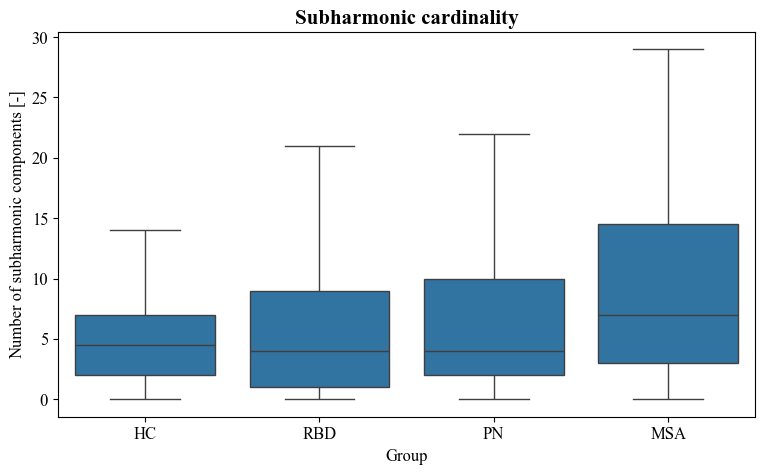

count    499.000000
mean       7.835671
std        9.338409
min        0.000000
25%        2.000000
50%        5.000000
75%       10.000000
max       51.000000
Name: subharm_num, dtype: float64


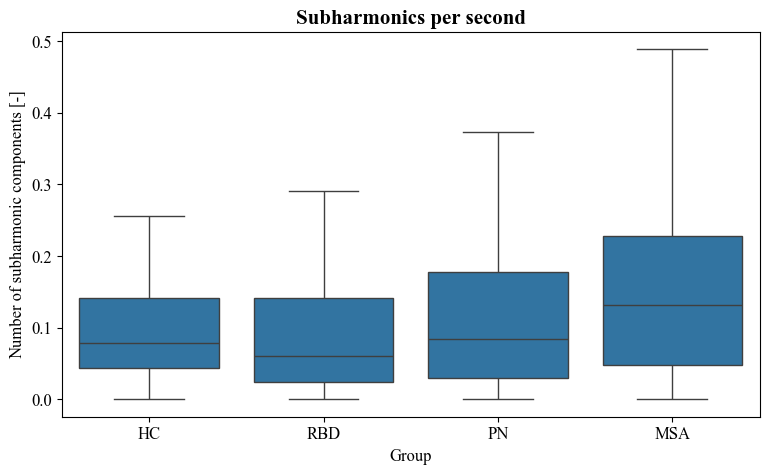

count    499.000000
mean       0.111814
std        0.101416
min        0.000000
25%        0.032881
50%        0.086477
75%        0.162991
max        0.563306
Name: subharm_per_second, dtype: float64


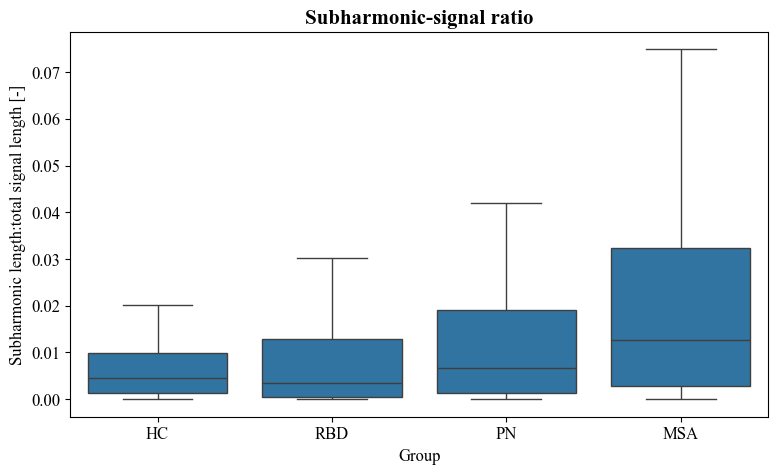

count    499.000000
mean       0.014672
std        0.027549
min        0.000000
25%        0.001341
50%        0.005542
75%        0.016252
max        0.235000
Name: subharm_sig_ratio, dtype: float64


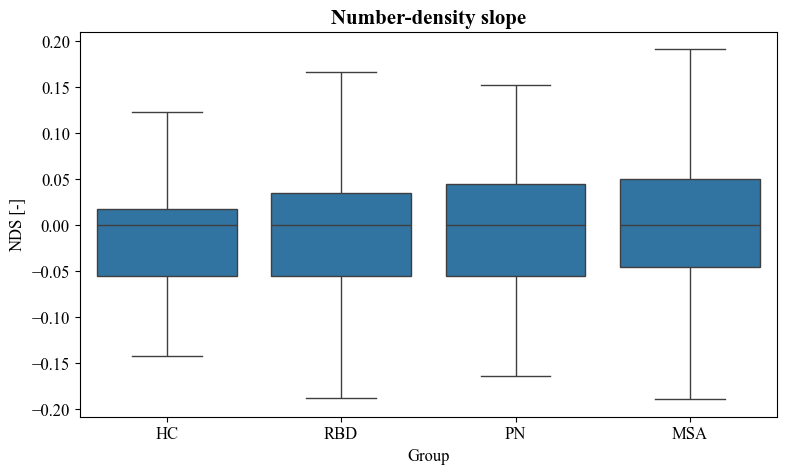

count    499.000000
mean      -0.004352
std        0.085981
min       -0.325776
25%       -0.053164
50%        0.000000
75%        0.044238
max        0.366972
Name: density_num_slope, dtype: float64


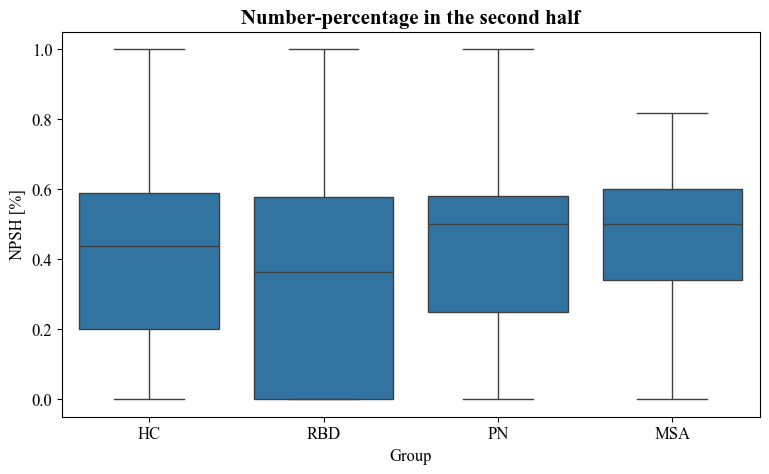

count    499.000000
mean       0.421945
std        0.299972
min        0.000000
25%        0.200000
50%        0.465116
75%        0.600000
max        1.000000
Name: pct_subharm_num_2nd_half, dtype: float64


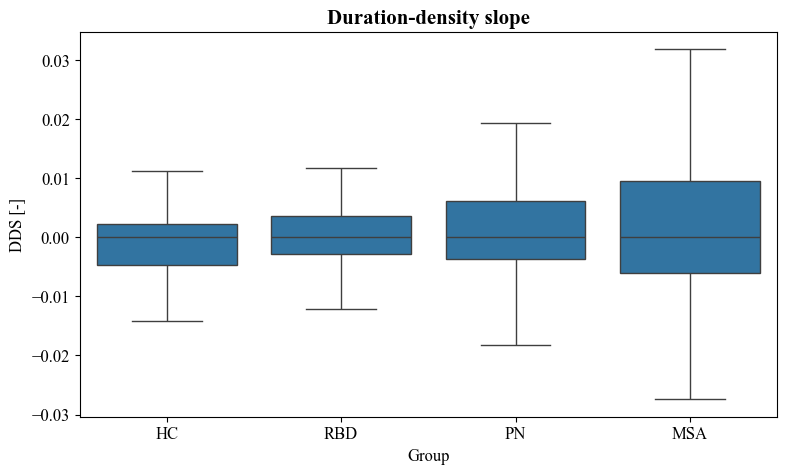

count    499.000000
mean       0.001964
std        0.022743
min       -0.074562
25%       -0.003841
50%        0.000000
75%        0.004409
max        0.250830
Name: density_dur_slope, dtype: float64


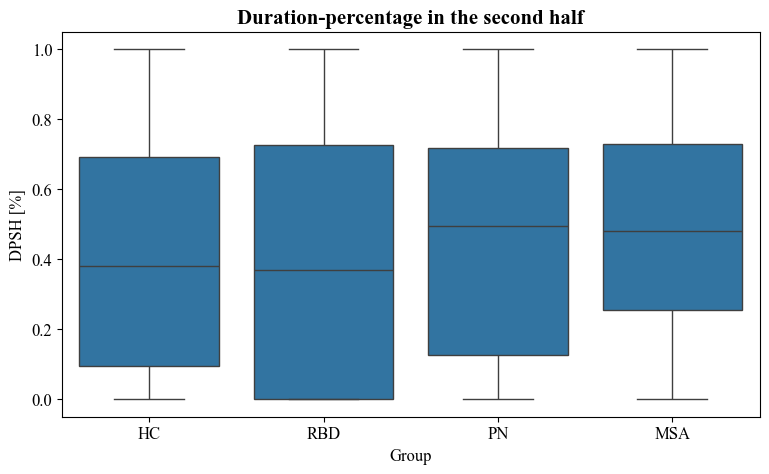

count    498.000000
mean       0.436691
std        0.342009
min        0.000000
25%        0.093205
50%        0.420109
75%        0.720764
max        1.000000
Name: pct_subharm_dur_2nd_half, dtype: float64


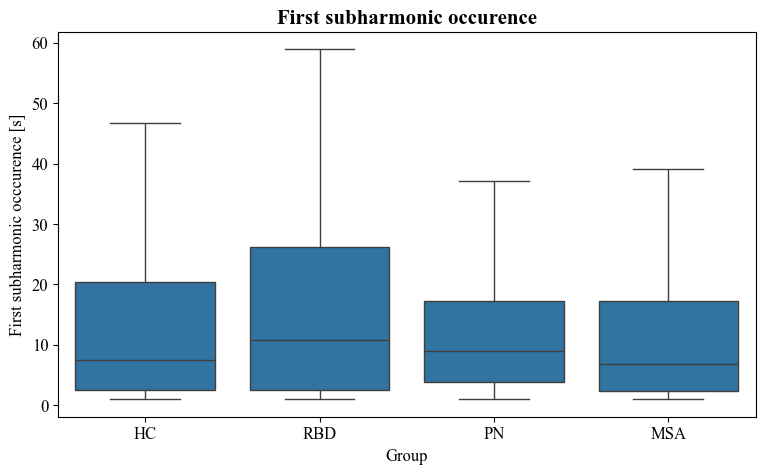

count    499.000000
mean      15.172828
std       17.424395
min        1.004708
25%        2.602542
50%        7.812789
75%       21.184703
max      122.489187
Name: first_occur, dtype: float64


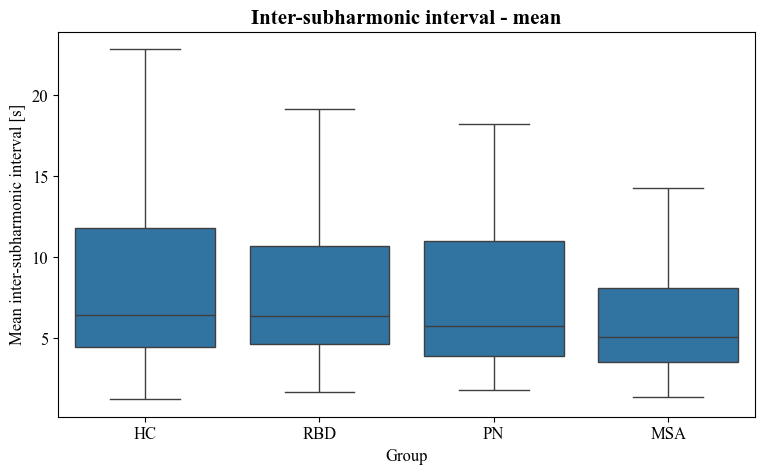

count    377.000000
mean       8.565116
std        7.737276
min        1.241667
25%        3.971250
50%        6.087500
75%       10.762500
max       84.393750
Name: mean_inter_intervals, dtype: float64


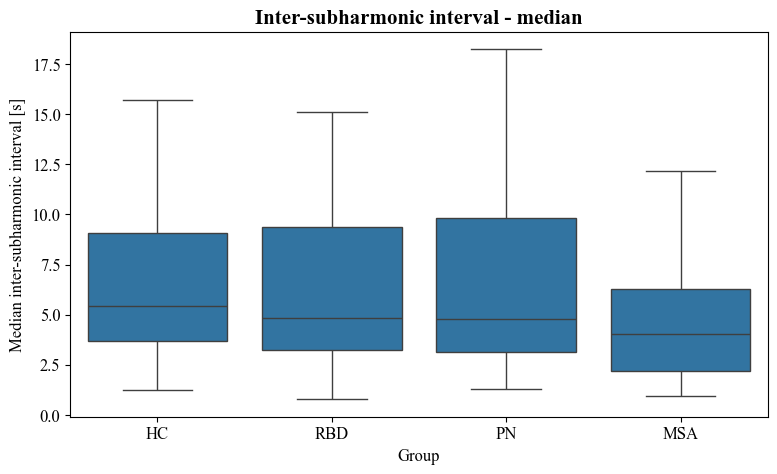

count    377.000000
mean       7.335095
std        7.754234
min        0.782143
25%        3.079688
50%        4.714286
75%        8.955000
max       84.393750
Name: median_inter_intervals, dtype: float64


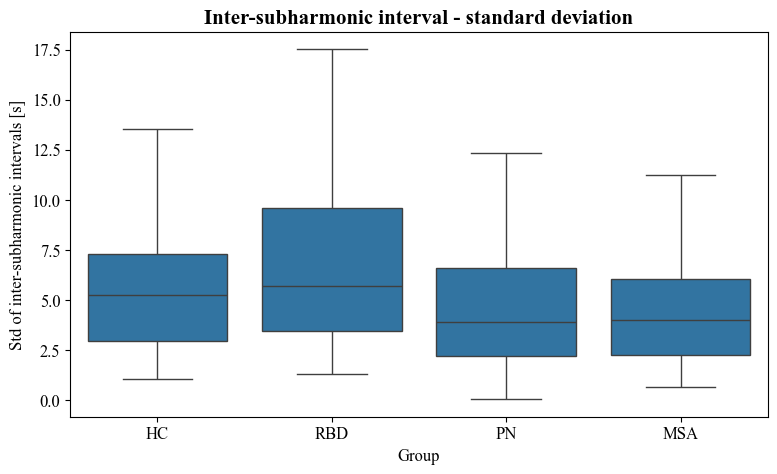

count    336.000000
mean       6.406691
std        5.895668
min        0.045457
25%        2.626870
50%        4.593430
75%        7.271642
max       37.389796
Name: std_inter_intervals, dtype: float64


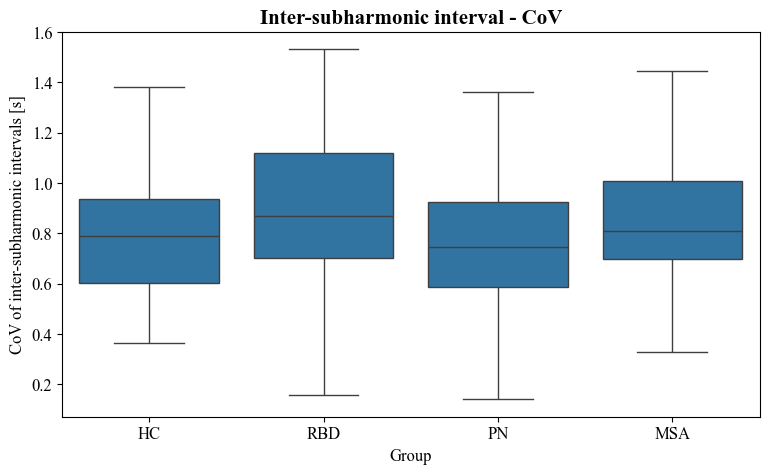

count    336.000000
mean       0.818040
std        0.300310
min        0.012169
25%        0.647816
50%        0.798920
75%        0.988105
max        1.900167
Name: COV_inter_intervals, dtype: float64


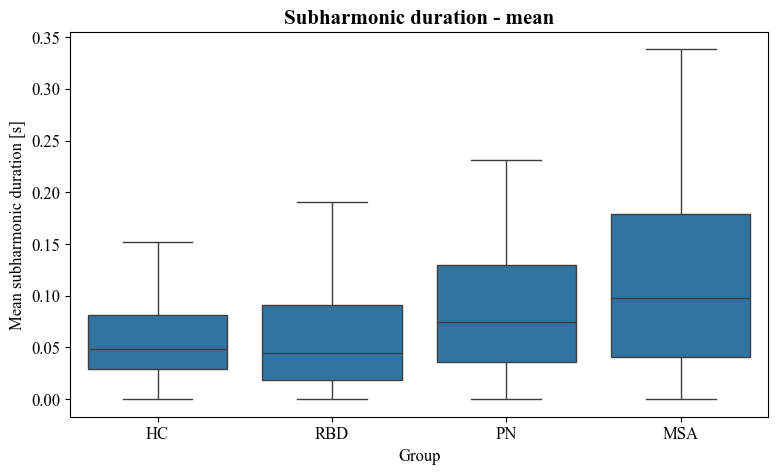

count    499.000000
mean       0.087023
std        0.089740
min        0.000000
25%        0.030000
50%        0.061538
75%        0.124066
max        0.575000
Name: avg_dur, dtype: float64


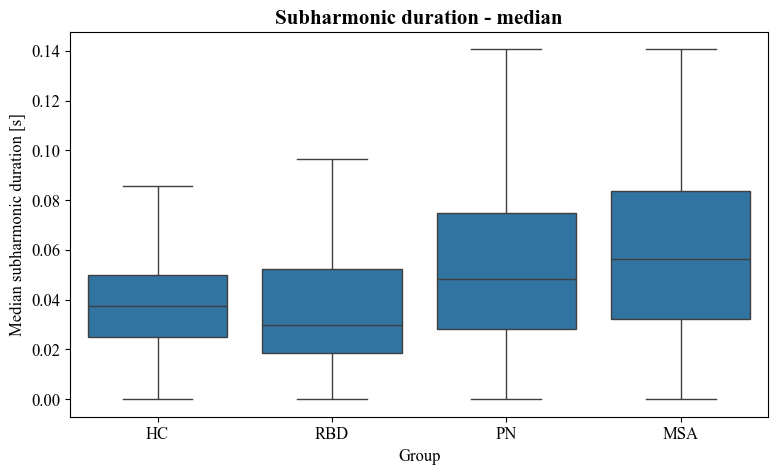

count    499.000000
mean       0.055901
std        0.067555
min        0.000000
25%        0.025000
50%        0.037500
75%        0.064286
max        0.575000
Name: median_dur, dtype: float64


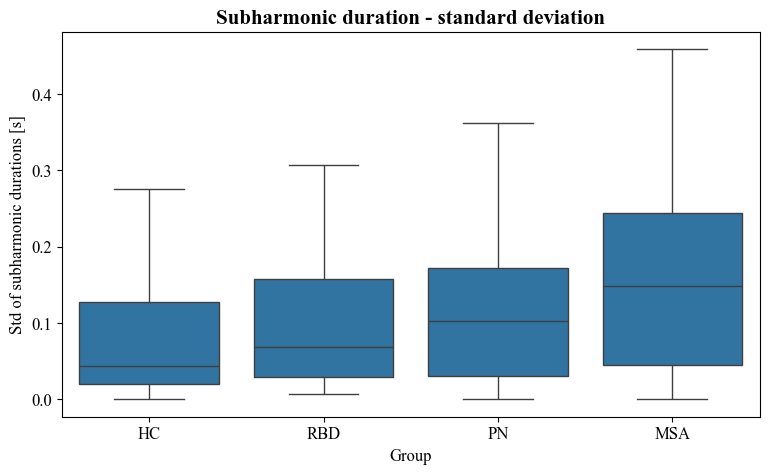

count    377.000000
mean       0.118960
std        0.116061
min        0.000000
25%        0.027599
50%        0.084971
75%        0.176014
max        0.680240
Name: std_dur, dtype: float64


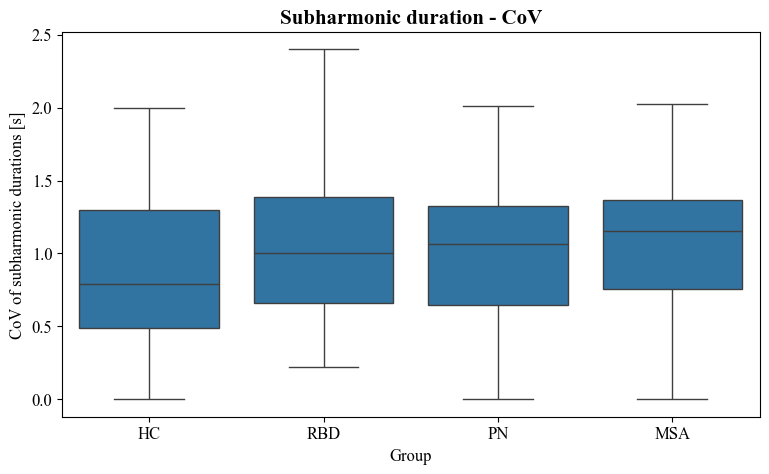

count    377.000000
mean       0.998826
std        0.474683
min        0.000000
25%        0.603023
50%        1.057423
75%        1.345856
max        2.401495
Name: CV_dur, dtype: float64


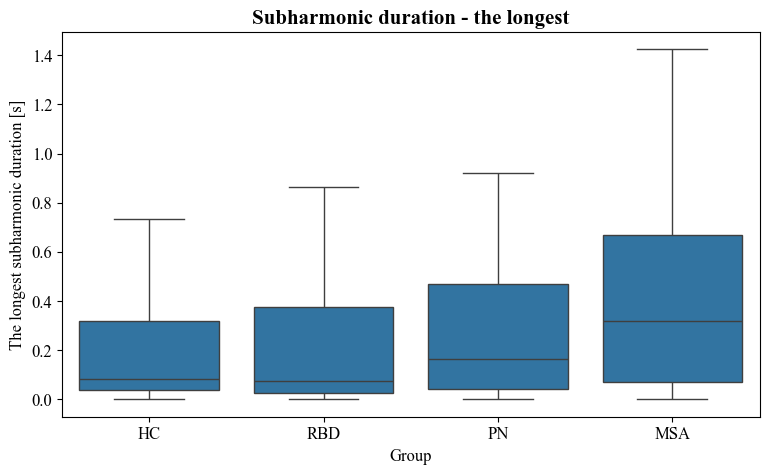

count    499.000000
mean       0.299998
std        0.390113
min        0.000000
25%        0.037500
50%        0.125000
75%        0.454167
max        2.793750
Name: longest_dur, dtype: float64


In [9]:

for i, (var, ydata, title) in enumerate(zip(variables.keys(), ylabels, variables.values())):
    plt.figure(figsize=(9,5))
    sns.boxplot(data=df_results_overall, x="group", y=var, order=groups, showfliers=False)
    plt.title(title, fontweight="bold")
    plt.ylabel(ydata)
    plt.xlabel("Group")
    plt.savefig(f"cont_speech_boxplots/boxplot_{title}", dpi=300)
    plt.show()

    print(df_results_overall[var].describe())

---------------------------------------------------------------
                     Subharmonic cardinality
---------------------------------------------------------------

Group medians:
group
HC     4.5
MSA    7.0
PN     4.0
RBD    4.0
Name: subharm_num, dtype: float64

Group means:
group
HC      6.166667
MSA    11.032520
PN      8.056000
RBD     6.152000
Name: subharm_num, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1          H     p-unc
Kruskal  group      3  18.977345  0.000276
Effect eta squared: 0.0323
Effect epsilon squared: 0.0381

Mean ranks
group
HC     236.603175
MSA    297.142276
PN     244.244000
RBD    222.872000
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.004457  0.898446  0.898446
MSA  0.004457  1.000000  0.015040  0.000284
PN   0.898446  0.015040  1.000000  0.719445
RBD  0.898446  0.000284  0.719445  1.000000
           HC       RB

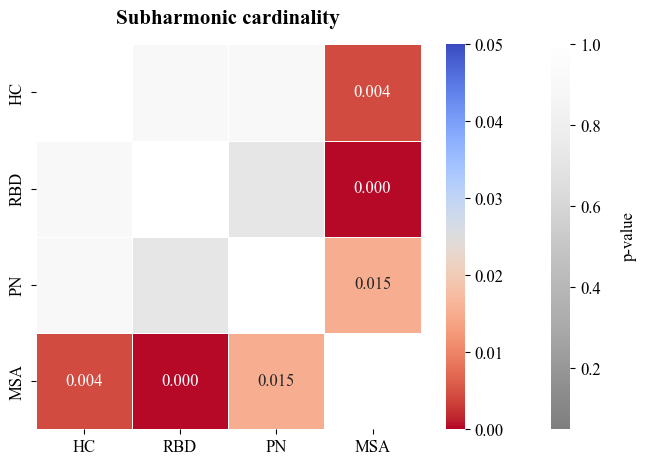


---------------------------------------------------------------
                     Subharmonics per second
---------------------------------------------------------------

Group medians:
group
HC     0.078395
MSA    0.131065
PN     0.084598
RBD    0.059988
Name: subharm_per_second, dtype: float64

Group means:
group
HC     0.092542
MSA    0.156349
PN     0.111351
RBD    0.087879
Name: subharm_per_second, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1          H     p-unc
Kruskal  group      3  24.810271  0.000017
Effect eta squared: 0.0441
Effect epsilon squared: 0.0498

Mean ranks
group
HC     235.956349
MSA    301.447154
PN     249.780000
RBD    213.752000
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.001670  0.447076  0.443993
MSA  0.001670  1.000000  0.018937  0.000010
PN   0.447076  0.018937  1.000000  0.143922
RBD  0.443993  0.000010  0.143922  

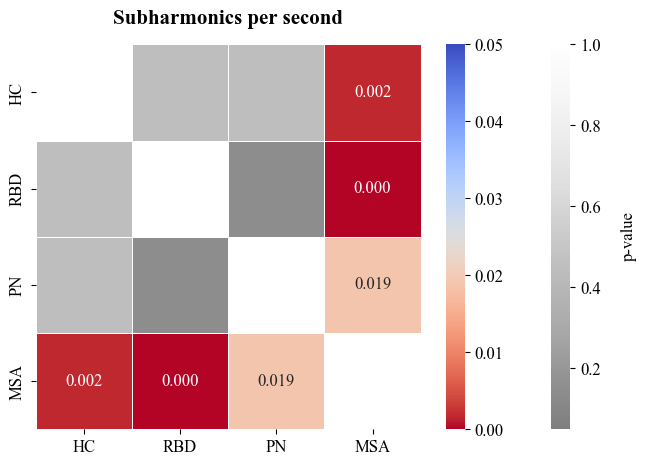


---------------------------------------------------------------
                     Subharmonic-signal ratio
---------------------------------------------------------------

Group medians:
group
HC     0.004520
MSA    0.012620
PN     0.006604
RBD    0.003411
Name: subharm_sig_ratio, dtype: float64

Group means:
group
HC     0.006595
MSA    0.027463
PN     0.015563
RBD    0.009338
Name: subharm_sig_ratio, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1        H         p-unc
Kruskal  group      3  34.4327  1.605330e-07
Effect eta squared: 0.0635
Effect epsilon squared: 0.0691

Mean ranks
group
HC     219.992063
MSA    308.430894
PN     259.560000
RBD    213.192000
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.000006  0.059059  0.708387
MSA  0.000006  1.000000  0.030173  0.000001
PN   0.059059  0.030173  1.000000  0.032755
RBD  0.708387  0.000001  0.03275

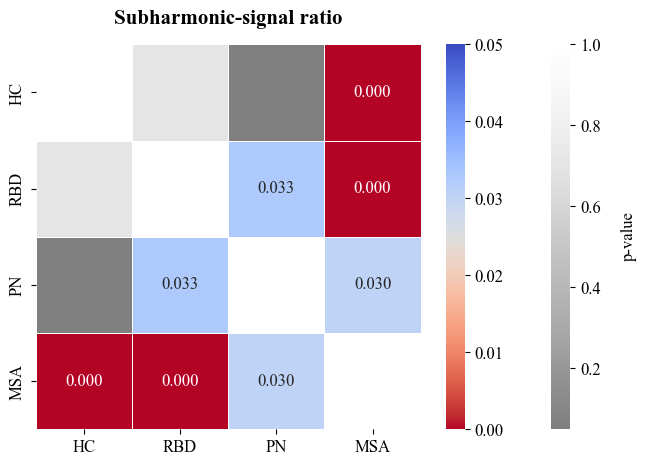


---------------------------------------------------------------
                     Number-density slope
---------------------------------------------------------------

Group medians:
group
HC     0.0
MSA    0.0
PN     0.0
RBD    0.0
Name: density_num_slope, dtype: float64

Group means:
group
HC    -0.014576
MSA    0.008784
PN    -0.002893
RBD   -0.008429
Name: density_num_slope, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1         H     p-unc
Kruskal  group      3  4.571017  0.206043
Effect eta squared: 0.0032
Effect epsilon squared: 0.0092

Mean ranks
group
HC     236.015873
MSA    271.382114
PN     252.560000
RBD    240.496000
Name: rank, dtype: float64

---------------------------------------------------------------
                     Number-percentage in the second half
---------------------------------------------------------------

Group medians:
group
HC     0.436508
MSA    0.500000
PN     0.500000
RBD    0.36363

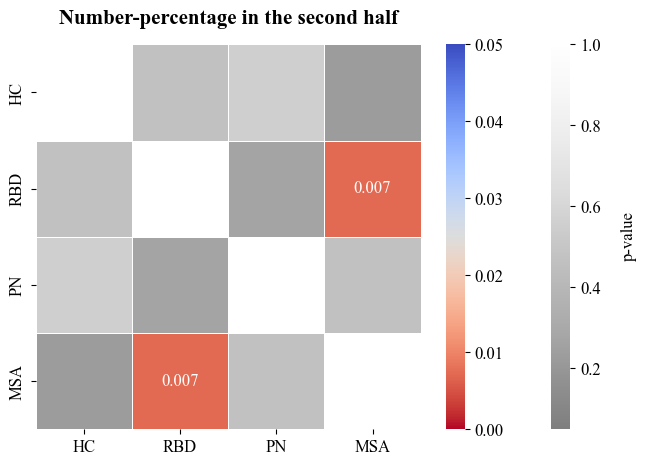


---------------------------------------------------------------
                     Duration-density slope
---------------------------------------------------------------

Group medians:
group
HC     0.0
MSA    0.0
PN     0.0
RBD    0.0
Name: density_dur_slope, dtype: float64

Group means:
group
HC    -0.000807
MSA    0.005415
PN     0.002357
RBD    0.000969
Name: density_dur_slope, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1         H     p-unc
Kruskal  group      3  2.934197  0.401882
Effect eta squared: -0.0001
Effect epsilon squared: 0.0059

Mean ranks
group
HC     231.825397
MSA    256.252033
PN     260.632000
RBD    251.536000
Name: rank, dtype: float64

---------------------------------------------------------------
                     Duration-percentage in the second half
---------------------------------------------------------------

Group medians:
group
HC     0.379791
MSA    0.480392
PN     0.495910
RBD  

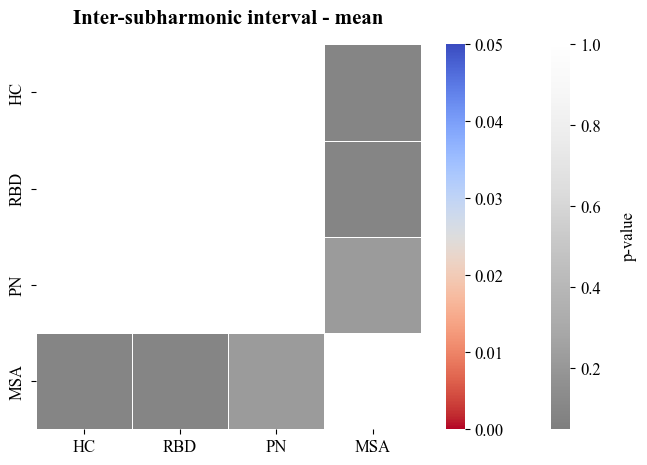


---------------------------------------------------------------
                     Inter-subharmonic interval - median
---------------------------------------------------------------

Group medians:
group
HC     5.414167
MSA    4.054687
PN     4.766518
RBD    4.818750
Name: median_inter_intervals, dtype: float64

Group means:
group
HC     7.374845
MSA    5.780217
PN     8.706266
RBD    7.626109
Name: median_inter_intervals, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1          H     p-unc
Kruskal  group      3  13.643782  0.003432
Effect eta squared: 0.0285
Effect epsilon squared: 0.0363

Mean ranks
group
HC     208.610000
MSA    156.039216
PN     199.697917
RBD    193.734177
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.003648  1.000000  1.000000
MSA  0.003648  1.000000  0.024207  0.084001
PN   1.000000  0.024207  1.000000  1.000000
RBD  1.000000  0.08

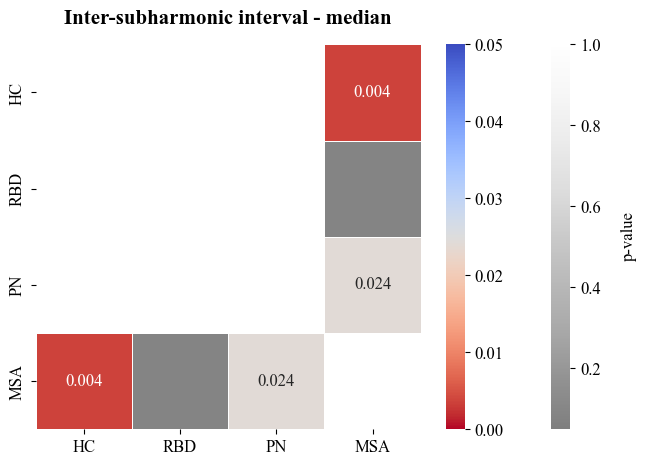


---------------------------------------------------------------
                     Inter-subharmonic interval - standard deviation
---------------------------------------------------------------

Group medians:
group
HC     5.238911
MSA    4.017221
PN     3.882036
RBD    5.708433
Name: std_inter_intervals, dtype: float64

Group means:
group
HC     6.590980
MSA    5.937022
PN     5.362787
RBD    7.955797
Name: std_inter_intervals, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1          H     p-unc
Kruskal  group      3  15.015109  0.001804
Effect eta squared: 0.0362
Effect epsilon squared: 0.0448

Mean ranks
group
HC     182.511905
MSA    152.020619
PN     147.222222
RBD    197.486486
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.105601  0.078616  0.667174
MSA  0.105601  1.000000  0.742771  0.012128
PN   0.078616  0.742771  1.000000  0.007751
RBD  0.667174

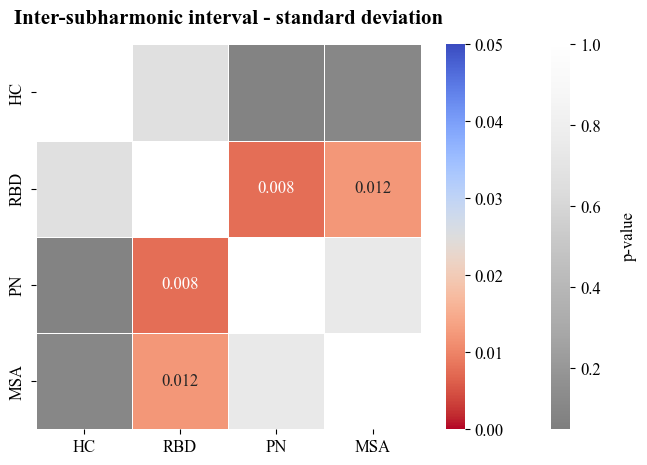


---------------------------------------------------------------
                     Inter-subharmonic interval - CoV
---------------------------------------------------------------

Group medians:
group
HC     0.788570
MSA    0.808522
PN     0.744830
RBD    0.869516
Name: COV_inter_intervals, dtype: float64

Group means:
group
HC     0.787913
MSA    0.832174
PN     0.754654
RBD    0.903094
Name: COV_inter_intervals, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1         H     p-unc
Kruskal  group      3  8.791389  0.032197
Effect eta squared: 0.0174
Effect epsilon squared: 0.0262

Mean ranks
group
HC     158.619048
MSA    174.082474
PN     149.876543
RBD    192.783784
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.636828  0.636828  0.136910
MSA  0.636828  1.000000  0.391240  0.636828
PN   0.636828  0.391240  1.000000  0.036106
RBD  0.136910  0.636828  0.036

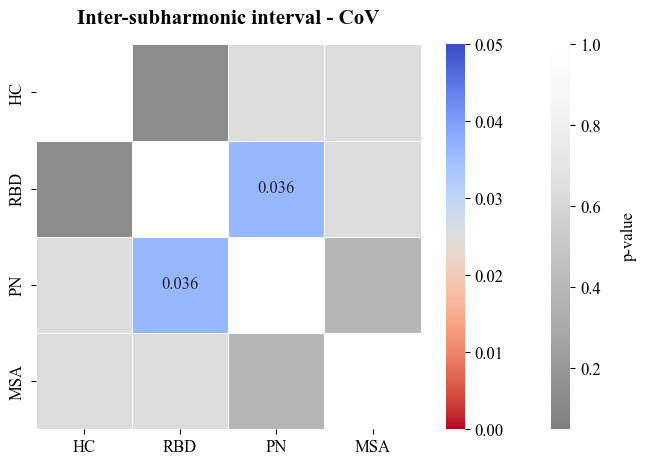


---------------------------------------------------------------
                     Subharmonic duration - mean
---------------------------------------------------------------

Group medians:
group
HC     0.048375
MSA    0.097500
PN     0.075000
RBD    0.045000
Name: avg_dur, dtype: float64

Group means:
group
HC     0.060037
MSA    0.123399
PN     0.096398
RBD    0.069058
Name: avg_dur, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1          H         p-unc
Kruskal  group      3  38.512215  2.201837e-08
Effect eta squared: 0.0717
Effect epsilon squared: 0.0773

Mean ranks
group
HC     213.400794
MSA    308.626016
PN     266.452000
RBD    212.752000
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
               HC           MSA        PN           RBD
HC   1.000000e+00  9.550287e-07  0.012802  9.715331e-01
MSA  9.550287e-07  1.000000e+00  0.042251  9.550287e-07
PN   1.280196e-02  4.225070e-02  1.000000  1.280196e-

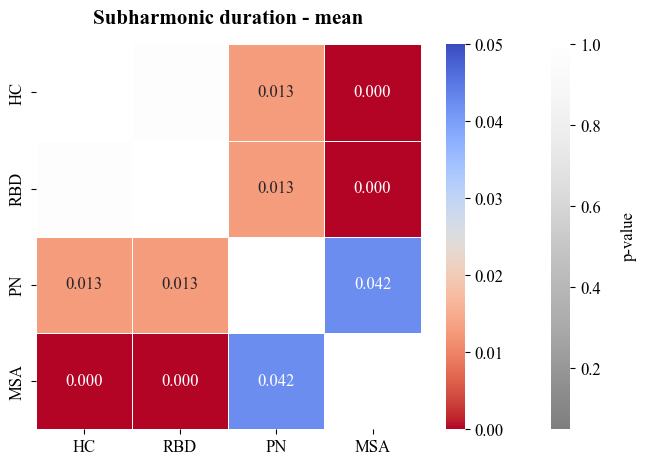


---------------------------------------------------------------
                     Subharmonic duration - median
---------------------------------------------------------------

Group medians:
group
HC     0.037500
MSA    0.056250
PN     0.048214
RBD    0.030000
Name: median_dur, dtype: float64

Group means:
group
HC     0.040928
MSA    0.072434
PN     0.064504
RBD    0.046120
Name: median_dur, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1          H         p-unc
Kruskal  group      3  37.391364  3.802554e-08
Effect eta squared: 0.0695
Effect epsilon squared: 0.0751

Mean ranks
group
HC     218.206349
MSA    301.170732
PN     275.772000
RBD    205.924000
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.000027  0.004624  0.499248
MSA  0.000027  1.000000  0.329775  0.000001
PN   0.004624  0.329775  1.000000  0.000503
RBD  0.499248  0.000001  0.000503  1.

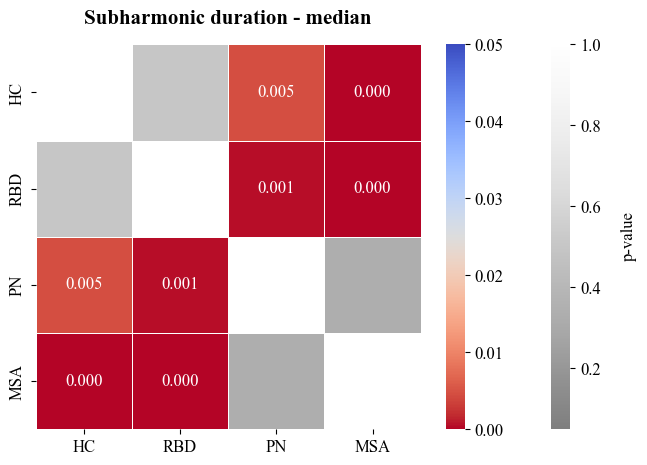


---------------------------------------------------------------
                     Subharmonic duration - standard deviation
---------------------------------------------------------------

Group medians:
group
HC     0.044158
MSA    0.148766
PN     0.101974
RBD    0.068892
Name: std_dur, dtype: float64

Group means:
group
HC     0.078506
MSA    0.161785
PN     0.127087
RBD    0.104996
Name: std_dur, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1          H     p-unc
Kruskal  group      3  26.602575  0.000007
Effect eta squared: 0.0633
Effect epsilon squared: 0.0708

Mean ranks
group
HC     150.365000
MSA    227.892157
PN     196.015625
RBD    179.164557
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.000003  0.014249  0.158284
MSA  0.000003  1.000000  0.119039  0.014249
PN   0.014249  0.119039  1.000000  0.308696
RBD  0.158284  0.014249  0.308696  1.00

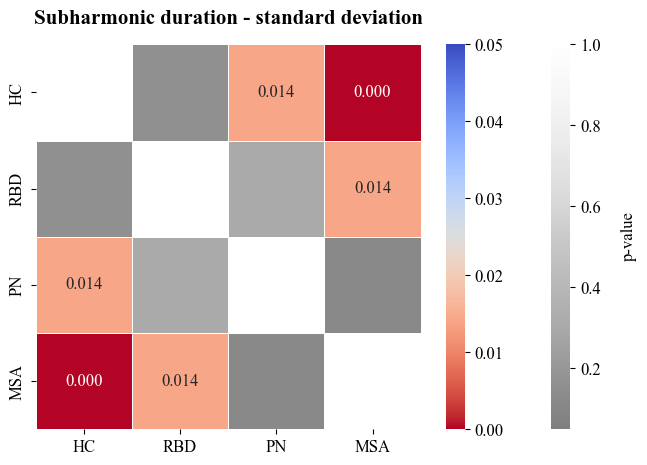


---------------------------------------------------------------
                     Subharmonic duration - CoV
---------------------------------------------------------------

Group medians:
group
HC     0.791417
MSA    1.156507
PN     1.061832
RBD    1.002064
Name: CV_dur, dtype: float64

Group means:
group
HC     0.901431
MSA    1.067865
PN     1.002119
RBD    1.028972
Name: CV_dur, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1         H    p-unc
Kruskal  group      3  7.128268  0.06792
Effect eta squared: 0.0111
Effect epsilon squared: 0.0190

Mean ranks
group
HC     166.715000
MSA    206.647059
PN     188.250000
RBD    195.335443
Name: rank, dtype: float64

---------------------------------------------------------------
                     Subharmonic duration - the longest
---------------------------------------------------------------

Group medians:
group
HC     0.08250
MSA    0.31875
PN     0.16250
RBD    0.07500
Na

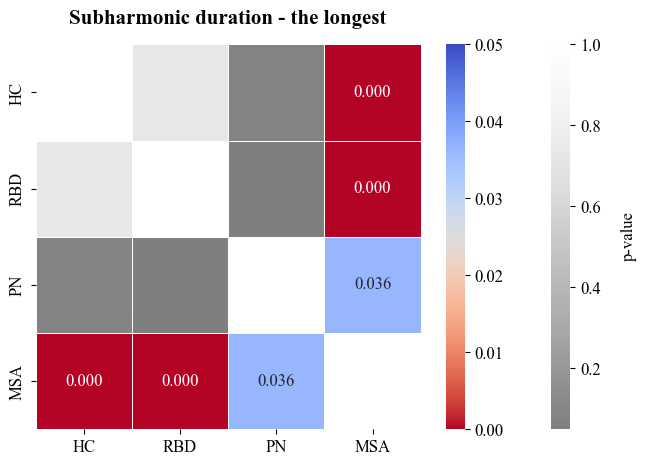

In [ ]:
# OVERALL STATS

posthoc_counter = 0
posthoc_results = []

for i, (dv, label) in enumerate(variables.items()):
    print("---------------------------------------------------------------")
    print(f"                     {label}")
    print("---------------------------------------------------------------")

    df_clean = df_results_overall.dropna(subset=[dv]).copy()

    # group_medians = df_clean[df_clean[dv] != 0].groupby("group")[dv].median()
    group_medians = df_clean.groupby("group")[dv].median()
    print("\nGroup medians:")
    print(group_medians)

    group_means = df_clean.groupby("group")[dv].mean()
    print("\nGroup means:")
    print(group_means)
    print()

    # Shapiro-Wilk normality test
    norm_results = pg.normality(data=df_clean, dv=dv, group="group") # -> norm_results.normal
    if norm_results.normal.all():
        print("NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<")
    else:
        print("NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<")

    # Levene homoscedasticity test
    homo_results = pg.homoscedasticity(data=df_clean, dv=dv, group="group") # -> homo_results.equal_var
    if homo_results.equal_var.iloc[0]:
        print("HOMO <<<<<<<<<<<<<<<<<<<<<<<<<")
    else:
        print("NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<")

    # KRUSKAL-WALLIS GROUP COMPARISON
    kw = pg.kruskal(data=df_clean, dv=dv, between="group")
    print(kw)
    H = kw["H"].values[0]
    k = len(groups)
    n = len(df_clean)
    eta_sq = (H-k+1)/(n-k)
    eps_sq = H/(n-1)
    print(f"Effect eta squared: {eta_sq:.4f}")
    print(f"Effect epsilon squared: {eps_sq:.4f}")

    print("\nMean ranks")
    df_clean["rank"] = df_clean[dv].rank()
    mean_ranks = df_clean.groupby("group")["rank"].mean()
    print(mean_ranks)

    pval = kw["p-unc"].values[0]
    # POST-HOC TEST
    if pval <= 0.05:
        posthoc_counter += 1
        print()
        print("TIME FOR DUNN POST-HOC TEST")
        dunn = sp.posthoc_dunn(df_clean, val_col=dv, group_col="group", p_adjust="holm")
        print(dunn)
        dunn = dunn.loc[groups, groups]
        print(dunn)
        reject = (dunn < 0.05)

        posthoc_results.append({"counter": posthoc_counter, "label": label, "dunn": dunn.copy()})

        n_ticks = 6
        ticks_grey = np.round(np.linspace(0.05, 1.0, n_ticks), 1)   # 1.0 → 0.05
        ticks_color = np.linspace(0.0, 0.05, n_ticks)

        plt.figure(figsize=(8, 5))
        sns.heatmap(dunn, mask=reject, fmt=".3f", cmap='Greys_r', cbar=True, linewidths=0.5, alpha = 0.5, cbar_kws={"label": "p-value", "ticks": ticks_grey}, square=True, vmin=0.05, vmax=1.0)
        sns.heatmap(dunn, mask=~reject, fmt=".3f", cmap='coolwarm_r', cbar=True, linewidths=0.5, annot=True, annot_kws={"size": 12}, square=True, vmin=0.0, vmax=0.05, cbar_kws={"ticks": ticks_color})
        cbar = plt.gca().collections[0].colorbar
        cbar.set_label("p-value", labelpad=15)
        plt.title(f"{label}", fontsize=15, pad=15, fontweight="bold")
        plt.savefig(f"posthoc/overall/{label}_posthoc.png", dpi=300)
        plt.show()
    
    print()

---------------------------------------------------------------
                     Subharmonic cardinality
---------------------------------------------------------------

Group medians:
group
HC      9.5
MSA    17.5
PN     15.5
RBD    11.0
Name: subharm_num, dtype: float64

Group means:
group
HC     11.880952
MSA    20.000000
PN     17.190476
RBD    12.609756
Name: subharm_num, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1         H     p-unc
Kruskal  group      3  7.749087  0.051492
Effect eta squared: 0.0291
Effect epsilon squared: 0.0467

Mean ranks
group
HC     71.595238
MSA    97.630952
PN     90.059524
RBD    76.536585
Name: rank, dtype: float64

---------------------------------------------------------------
                     Subharmonics per second
---------------------------------------------------------------

Group medians:
group
HC     0.075608
MSA    0.137506
PN     0.117853
RBD    0.099628
Name: subharm

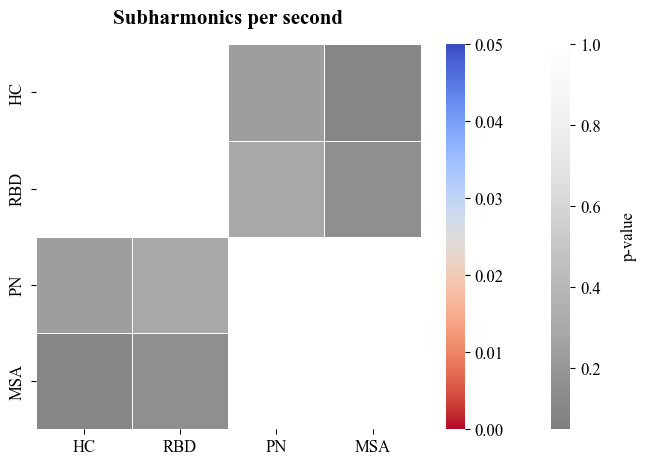


---------------------------------------------------------------
                     Subharmonic-signal ratio
---------------------------------------------------------------

Group medians:
group
HC     0.006626
MSA    0.018838
PN     0.013226
RBD    0.004697
Name: subharm_sig_ratio, dtype: float64

Group means:
group
HC     0.008991
MSA    0.029813
PN     0.024818
RBD    0.009794
Name: subharm_sig_ratio, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1          H     p-unc
Kruskal  group      3  16.571254  0.000866
Effect eta squared: 0.0833
Effect epsilon squared: 0.0998

Mean ranks
group
HC      70.547619
MSA    103.000000
PN      94.619048
RBD     67.439024
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.010503  0.067586  0.854050
MSA  0.010503  1.000000  0.854050  0.004851
PN   0.067586  0.854050  1.000000  0.041823
RBD  0.854050  0.004851  0.041823  1

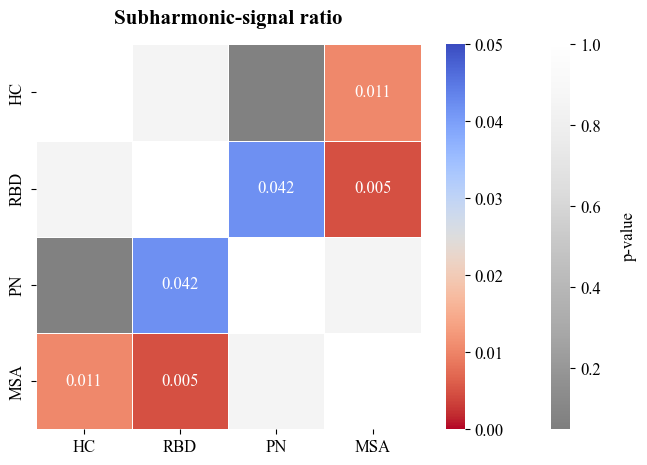


---------------------------------------------------------------
                     Number-density slope
---------------------------------------------------------------

Group medians:
group
HC    -0.006382
MSA    0.012689
PN     0.000000
RBD   -0.013087
Name: density_num_slope, dtype: float64

Group means:
group
HC    -0.006834
MSA    0.011441
PN     0.001289
RBD   -0.015954
Name: density_num_slope, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1         H     p-unc
Kruskal  group      3  4.073565  0.253629
Effect eta squared: 0.0066
Effect epsilon squared: 0.0245

Mean ranks
group
HC     78.952381
MSA    95.642857
PN     85.285714
RBD    75.926829
Name: rank, dtype: float64

---------------------------------------------------------------
                     Number-percentage in the second half
---------------------------------------------------------------

Group medians:
group
HC     0.488095
MSA    0.514286
PN     0.50000

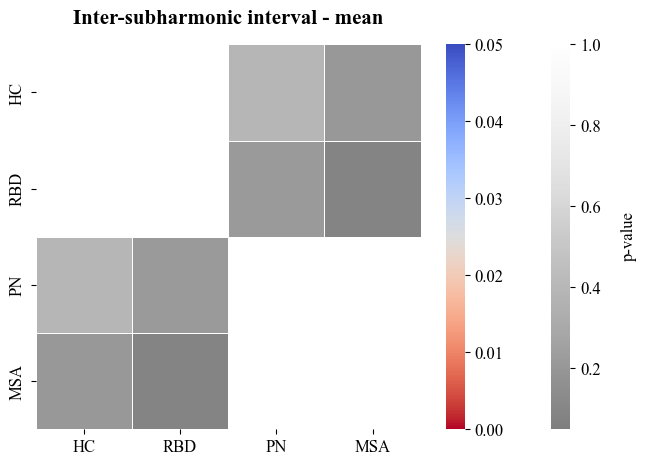


---------------------------------------------------------------
                     Inter-subharmonic interval - median
---------------------------------------------------------------

Group medians:
group
HC     5.797031
MSA    4.509375
PN     4.493304
RBD    6.137917
Name: median_inter_intervals, dtype: float64

Group means:
group
HC     8.415452
MSA    6.792267
PN     9.558278
RBD    9.661951
Name: median_inter_intervals, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1         H     p-unc
Kruskal  group      3  7.867124  0.048839
Effect eta squared: 0.0320
Effect epsilon squared: 0.0508

Mean ranks
group
HC     90.00
MSA    65.35
PN     72.65
RBD    87.00
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.096075  0.360057  0.939814
MSA  0.096075  1.000000  0.939814  0.171941
PN   0.360057  0.939814  1.000000  0.482581
RBD  0.939814  0.171941  0.482581  1.0000

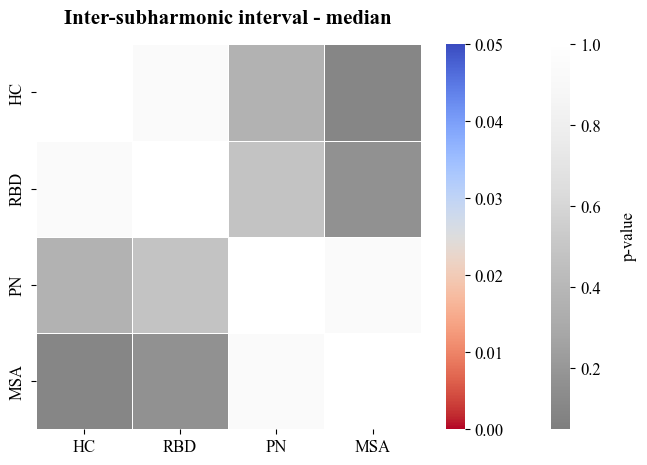


---------------------------------------------------------------
                     Inter-subharmonic interval - standard deviation
---------------------------------------------------------------

Group medians:
group
HC     7.160399
MSA    4.612840
PN     4.817333
RBD    8.337220
Name: std_inter_intervals, dtype: float64

Group means:
group
HC     10.032224
MSA     8.743487
PN      7.067452
RBD    11.483272
Name: std_inter_intervals, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1          H     p-unc
Kruskal  group      3  14.741096  0.002052
Effect eta squared: 0.0804
Effect epsilon squared: 0.0989

Mean ranks
group
HC     87.405405
MSA    63.282051
PN     60.945946
RBD    91.027027
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.046629  0.035220  1.000000
MSA  0.046629  1.000000  1.000000  0.026954
PN   0.035220  1.000000  1.000000  0.017404
RBD  1.000000

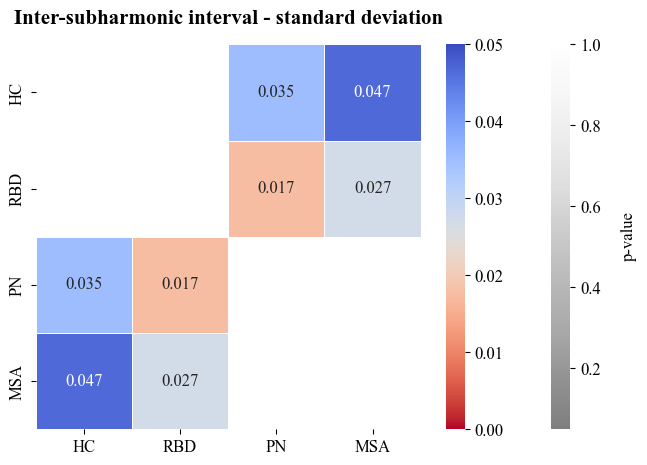


---------------------------------------------------------------
                     Inter-subharmonic interval - CoV
---------------------------------------------------------------

Group medians:
group
HC     0.919541
MSA    0.839042
PN     0.847859
RBD    0.948111
Name: COV_inter_intervals, dtype: float64

Group means:
group
HC     0.923500
MSA    0.923040
PN     0.907932
RBD    1.015758
Name: COV_inter_intervals, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1         H     p-unc
Kruskal  group      3  3.952074  0.266686
Effect eta squared: 0.0065
Effect epsilon squared: 0.0265

Mean ranks
group
HC     76.729730
MSA    71.179487
PN     67.810811
RBD    86.513514
Name: rank, dtype: float64

---------------------------------------------------------------
                     Subharmonic duration - mean
---------------------------------------------------------------

Group medians:
group
HC     0.075893
MSA    0.145714
PN     

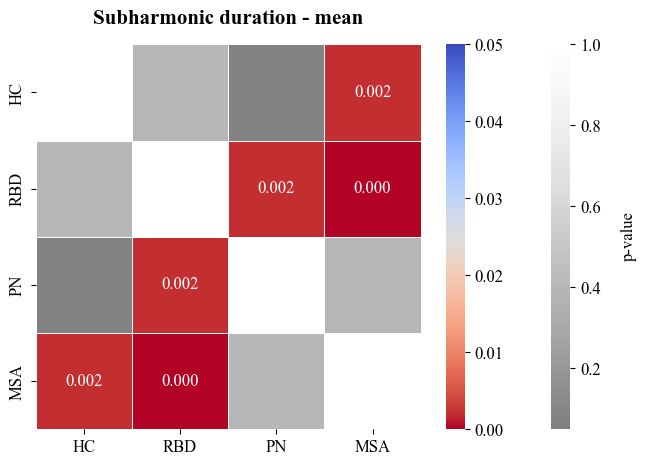


---------------------------------------------------------------
                     Subharmonic duration - median
---------------------------------------------------------------

Group medians:
group
HC     0.044375
MSA    0.075000
PN     0.058125
RBD    0.030000
Name: median_dur, dtype: float64

Group means:
group
HC     0.046113
MSA    0.079306
PN     0.071807
RBD    0.039191
Name: median_dur, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1          H     p-unc
Kruskal  group      3  26.349973  0.000008
Effect eta squared: 0.1433
Effect epsilon squared: 0.1587

Mean ranks
group
HC      74.880952
MSA    107.380952
PN      95.809524
RBD     57.292683
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.008240  0.141665  0.194827
MSA  0.008240  1.000000  0.272587  0.000014
PN   0.141665  0.272587  1.000000  0.001418
RBD  0.194827  0.000014  0.001418  1.000000
 

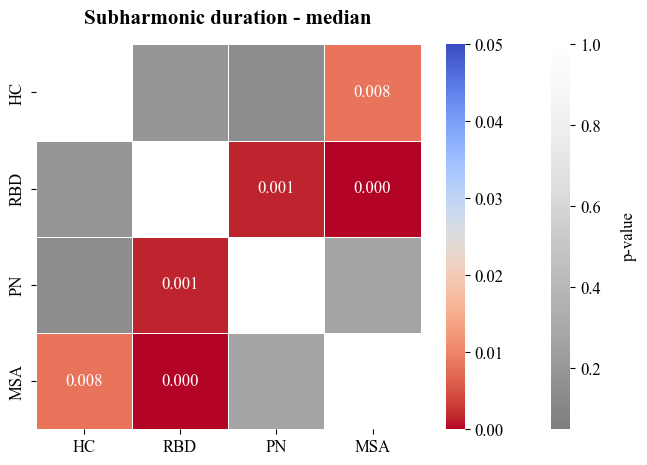


---------------------------------------------------------------
                     Subharmonic duration - standard deviation
---------------------------------------------------------------

Group medians:
group
HC     0.111475
MSA    0.161390
PN     0.149494
RBD    0.071166
Name: std_dur, dtype: float64

Group means:
group
HC     0.115144
MSA    0.188223
PN     0.159252
RBD    0.103336
Name: std_dur, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1          H     p-unc
Kruskal  group      3  13.640695  0.003437
Effect eta squared: 0.0700
Effect epsilon squared: 0.0880

Mean ranks
group
HC     70.105263
MSA    96.350000
PN     84.700000
RBD    61.578947
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.051669  0.461520  0.497624
MSA  0.051669  1.000000  0.497624  0.004079
PN   0.461520  0.497624  1.000000  0.095476
RBD  0.497624  0.004079  0.095476  1.000000
   

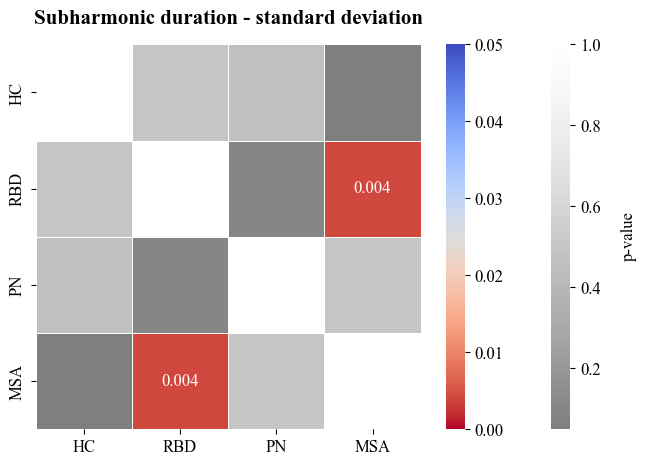


---------------------------------------------------------------
                     Subharmonic duration - CoV
---------------------------------------------------------------

Group medians:
group
HC     1.276609
MSA    1.273655
PN     1.179789
RBD    1.193916
Name: CV_dur, dtype: float64

Group means:
group
HC     1.188330
MSA    1.217498
PN     1.180181
RBD    1.186121
Name: CV_dur, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1         H     p-unc
Kruskal  group      3  0.347377  0.950885
Effect eta squared: -0.0175
Effect epsilon squared: 0.0022

Mean ranks
group
HC     80.184211
MSA    80.975000
PN     75.975000
RBD    76.868421
Name: rank, dtype: float64

---------------------------------------------------------------
                     Subharmonic duration - the longest
---------------------------------------------------------------

Group medians:
group
HC     0.350000
MSA    0.590625
PN     0.467812
RBD    0.22

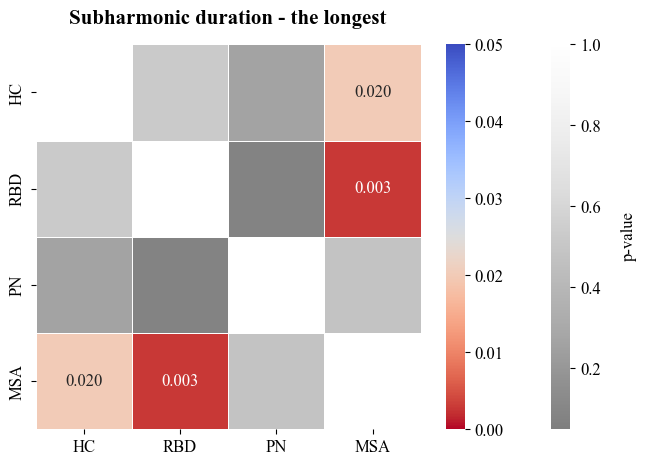

In [16]:
# MONOLOG STATS

posthoc_counter = 0
posthoc_results = []

for i, (dv, label) in enumerate(variables.items()):
    print("---------------------------------------------------------------")
    print(f"                     {label}")
    print("---------------------------------------------------------------")

    df_clean = df_results_monolog.dropna(subset=[dv]).copy()

    # group_medians = df_clean[df_clean[dv] != 0].groupby("group")[dv].median()
    group_medians = df_clean.groupby("group")[dv].median()
    print("\nGroup medians:")
    print(group_medians)

    group_means = df_clean.groupby("group")[dv].mean()
    print("\nGroup means:")
    print(group_means)
    print()

    # Shapiro-Wilk normality test
    norm_results = pg.normality(data=df_clean, dv=dv, group="group") # -> norm_results.normal
    if norm_results.normal.all():
        print("NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<")
    else:
        print("NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<")

    # Levene homoscedasticity test
    homo_results = pg.homoscedasticity(data=df_clean, dv=dv, group="group") # -> homo_results.equal_var
    if homo_results.equal_var.iloc[0]:
        print("HOMO <<<<<<<<<<<<<<<<<<<<<<<<<")
    else:
        print("NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<")

    # KRUSKAL-WALLIS GROUP COMPARISON
    kw = pg.kruskal(data=df_clean, dv=dv, between="group")
    print(kw)
    H = kw["H"].values[0]
    k = len(groups)
    n = len(df_clean)
    eta_sq = (H-k+1)/(n-k)
    eps_sq = H/(n-1)
    print(f"Effect eta squared: {eta_sq:.4f}")
    print(f"Effect epsilon squared: {eps_sq:.4f}")

    print("\nMean ranks")
    df_clean["rank"] = df_clean[dv].rank()
    mean_ranks = df_clean.groupby("group")["rank"].mean()
    print(mean_ranks)

    pval = kw["p-unc"].values[0]
    # POST-HOC TEST
    if pval <= 0.05:
        posthoc_counter += 1
        print()
        print("TIME FOR DUNN POST-HOC TEST")
        dunn = sp.posthoc_dunn(df_clean, val_col=dv, group_col="group", p_adjust="holm")
        print(dunn)
        dunn = dunn.loc[groups, groups]
        print(dunn)
        reject = (dunn < 0.05)

        posthoc_results.append({"counter": posthoc_counter, "label": label, "dunn": dunn.copy()})

        n_ticks = 6
        ticks_grey = np.round(np.linspace(0.05, 1.0, n_ticks), 1)   # 1.0 → 0.05
        ticks_color = np.linspace(0.0, 0.05, n_ticks)

        plt.figure(figsize=(8, 5))
        sns.heatmap(dunn, mask=reject, fmt=".3f", cmap='Greys_r', cbar=True, linewidths=0.5, alpha = 0.5, cbar_kws={"label": "p-value", "ticks": ticks_grey}, square=True, vmin=0.05, vmax=1.0)
        sns.heatmap(dunn, mask=~reject, fmt=".3f", cmap='coolwarm_r', cbar=True, linewidths=0.5, annot=True, annot_kws={"size": 12}, square=True, vmin=0.0, vmax=0.05, cbar_kws={"ticks": ticks_color})
        cbar = plt.gca().collections[0].colorbar
        cbar.set_label("p-value", labelpad=15)
        plt.title(f"{label}", fontsize=15, pad=15, fontweight="bold")
        plt.savefig(f"posthoc/monolog/{label}_posthoc.png", dpi=300)
        plt.show()
    
    print()

---------------------------------------------------------------
                     Subharmonic cardinality
---------------------------------------------------------------

Group medians:
group
HC     3.0
MSA    5.0
PN     3.0
RBD    1.0
Name: subharm_num, dtype: float64

Group means:
group
HC     3.309524
MSA    6.382716
PN     3.433735
RBD    3.000000
Name: subharm_num, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1          H     p-unc
Kruskal  group      3  24.195569  0.000023
Effect eta squared: 0.0646
Effect epsilon squared: 0.0731

Mean ranks
group
HC     161.363095
MSA    209.197531
PN     157.861446
RBD    139.000000
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.005052  0.812279  0.384584
MSA  0.005052  1.000000  0.002802  0.000013
PN   0.812279  0.002802  1.000000  0.401645
RBD  0.384584  0.000013  0.401645  1.000000
           HC       RBD   

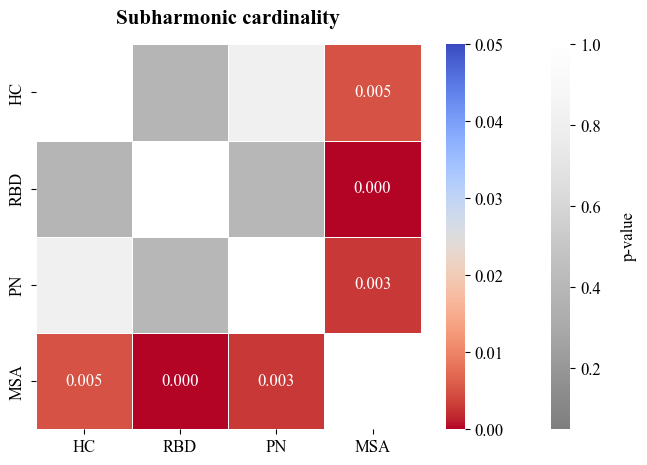


---------------------------------------------------------------
                     Subharmonics per second
---------------------------------------------------------------

Group medians:
group
HC     0.080271
MSA    0.126524
PN     0.071875
RBD    0.034806
Name: subharm_per_second, dtype: float64

Group means:
group
HC     0.090853
MSA    0.155598
PN     0.094950
RBD    0.082511
Name: subharm_per_second, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1          H     p-unc
Kruskal  group      3  19.442208  0.000221
Effect eta squared: 0.0501
Effect epsilon squared: 0.0587

Mean ranks
group
HC     163.642857
MSA    204.074074
PN     159.457831
RBD    140.083333
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.026499  0.777343  0.330991
MSA  0.026499  1.000000  0.014070  0.000104
PN   0.777343  0.014070  1.000000  0.380975
RBD  0.330991  0.000104  0.380975  

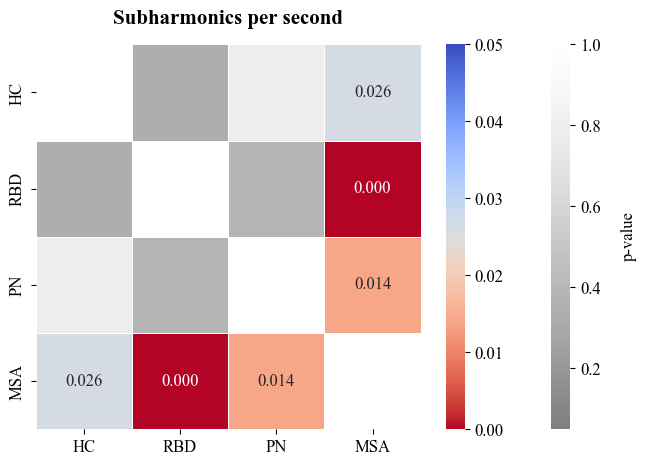


---------------------------------------------------------------
                     Subharmonic-signal ratio
---------------------------------------------------------------

Group medians:
group
HC     0.003150
MSA    0.009786
PN     0.003633
RBD    0.002091
Name: subharm_sig_ratio, dtype: float64

Group means:
group
HC     0.005397
MSA    0.026244
PN     0.010879
RBD    0.009116
Name: subharm_sig_ratio, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1        H     p-unc
Kruskal  group      3  20.9937  0.000106
Effect eta squared: 0.0549
Effect epsilon squared: 0.0634

Mean ranks
group
HC     149.773810
MSA    206.024691
PN     167.427711
RBD    144.196429
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.000790  0.465669  0.705382
MSA  0.000790  1.000000  0.038976  0.000197
PN   0.465669  0.038976  1.000000  0.349231
RBD  0.705382  0.000197  0.349231  1.000

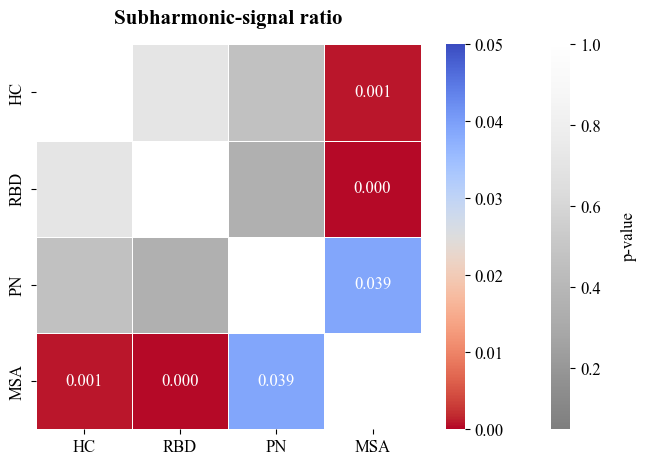


---------------------------------------------------------------
                     Number-density slope
---------------------------------------------------------------

Group medians:
group
HC     0.0
MSA    0.0
PN     0.0
RBD    0.0
Name: density_num_slope, dtype: float64

Group means:
group
HC    -0.018447
MSA    0.007406
PN    -0.005009
RBD   -0.004757
Name: density_num_slope, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1         H     p-unc
Kruskal  group      3  1.843055  0.605611
Effect eta squared: -0.0035
Effect epsilon squared: 0.0056

Mean ranks
group
HC     156.863095
MSA    176.623457
PN     167.271084
RBD    165.613095
Name: rank, dtype: float64

---------------------------------------------------------------
                     Number-percentage in the second half
---------------------------------------------------------------

Group medians:
group
HC     0.387500
MSA    0.500000
PN     0.444444
RBD    0.2500

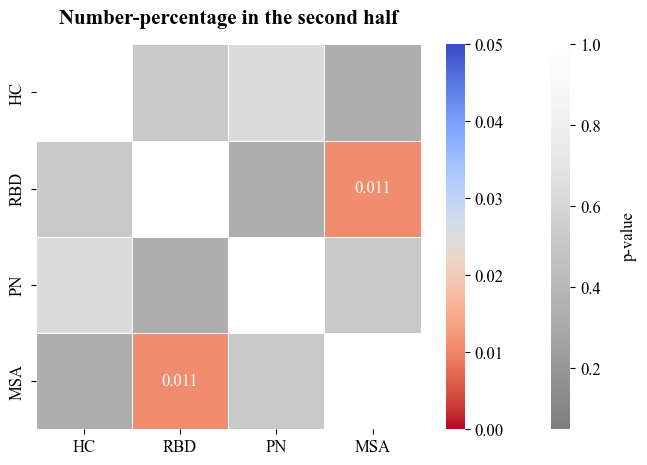


---------------------------------------------------------------
                     Duration-density slope
---------------------------------------------------------------

Group medians:
group
HC     0.0
MSA    0.0
PN     0.0
RBD    0.0
Name: density_dur_slope, dtype: float64

Group means:
group
HC    -0.000332
MSA    0.007238
PN     0.000849
RBD    0.001088
Name: density_dur_slope, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1         H    p-unc
Kruskal  group      3  0.975707  0.80713
Effect eta squared: -0.0062
Effect epsilon squared: 0.0029

Mean ranks
group
HC     159.464286
MSA    173.049383
PN     169.626506
RBD    164.130952
Name: rank, dtype: float64

---------------------------------------------------------------
                     Duration-percentage in the second half
---------------------------------------------------------------

Group medians:
group
HC     0.333333
MSA    0.422886
PN     0.343284
RBD    

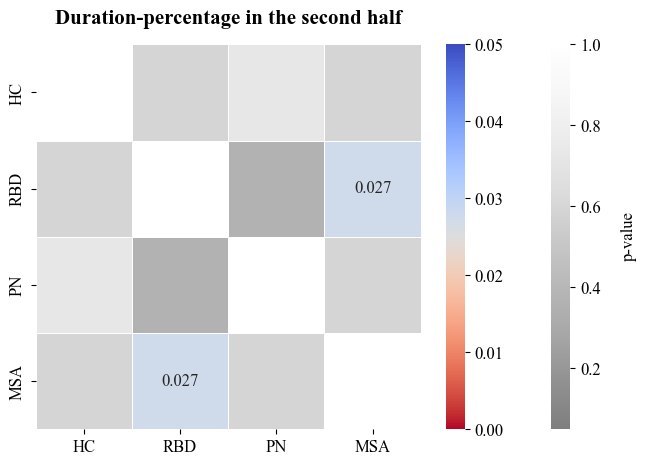


---------------------------------------------------------------
                     First subharmonic occurence
---------------------------------------------------------------

Group medians:
group
HC      7.348792
MSA     6.937484
PN      9.492635
RBD    12.169208
Name: first_occur, dtype: float64

Group means:
group
HC     13.125141
MSA    12.497670
PN     14.088536
RBD    17.470317
Name: first_occur, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1         H     p-unc
Kruskal  group      3  8.548227  0.035941
Effect eta squared: 0.0169
Effect epsilon squared: 0.0258

Mean ranks
group
HC     158.619048
MSA    147.617284
PN     169.807229
RBD    189.321429
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.902724  0.902724  0.190868
MSA  0.902724  1.000000  0.555298  0.031616
PN   0.902724  0.555298  1.000000  0.566920
RBD  0.190868  0.031616  0.566920  1.000000

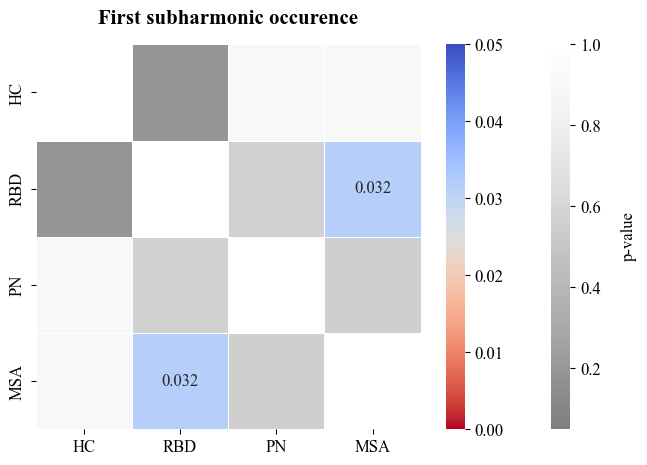


---------------------------------------------------------------
                     Inter-subharmonic interval - mean
---------------------------------------------------------------

Group medians:
group
HC     5.425312
MSA    4.687902
PN     5.477232
RBD    4.878750
Name: mean_inter_intervals, dtype: float64

Group means:
group
HC     7.056361
MSA    5.987251
PN     8.345505
RBD    6.286986
Name: mean_inter_intervals, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1         H     p-unc
Kruskal  group      3  4.671114  0.197526
Effect eta squared: 0.0077
Effect epsilon squared: 0.0212

Mean ranks
group
HC     115.451613
MSA     99.903226
PN     123.250000
RBD    104.317073
Name: rank, dtype: float64

---------------------------------------------------------------
                     Inter-subharmonic interval - median
---------------------------------------------------------------

Group medians:
group
HC     5.088750
MSA    3

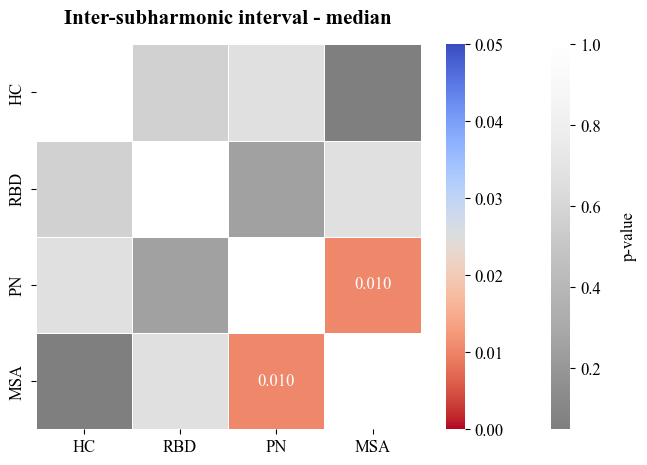


---------------------------------------------------------------
                     Inter-subharmonic interval - standard deviation
---------------------------------------------------------------

Group medians:
group
HC     3.098860
MSA    3.700953
PN     2.992408
RBD    3.390896
Name: std_inter_intervals, dtype: float64

Group means:
group
HC     3.881916
MSA    4.049916
PN     3.929319
RBD    4.428323
Name: std_inter_intervals, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1         H     p-unc
Kruskal  group      3  3.222369  0.358594
Effect eta squared: 0.0012
Effect epsilon squared: 0.0174

Mean ranks
group
HC      97.702128
MSA     92.741379
PN      82.386364
RBD    102.567568
Name: rank, dtype: float64

---------------------------------------------------------------
                     Inter-subharmonic interval - CoV
---------------------------------------------------------------

Group medians:
group
HC     0.645559

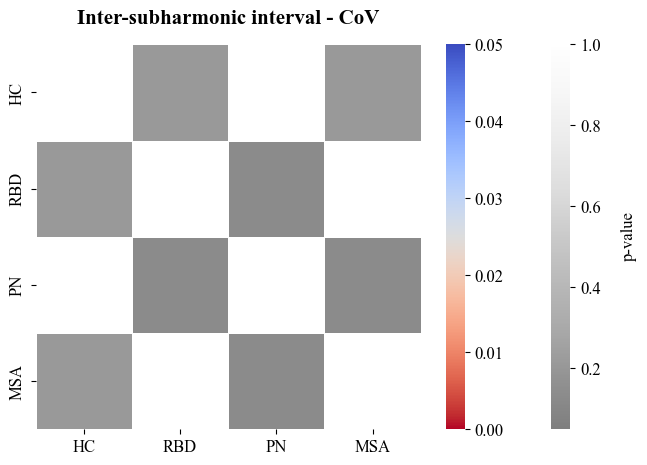


---------------------------------------------------------------
                     Subharmonic duration - mean
---------------------------------------------------------------

Group medians:
group
HC     0.037500
MSA    0.072500
PN     0.053571
RBD    0.037500
Name: avg_dur, dtype: float64

Group means:
group
HC     0.047815
MSA    0.111006
PN     0.080580
RBD    0.066256
Name: avg_dur, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1          H     p-unc
Kruskal  group      3  21.277275  0.000092
Effect eta squared: 0.0557
Effect epsilon squared: 0.0643

Mean ranks
group
HC     140.279762
MSA    202.561728
PN     175.295181
RBD    149.255952
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.000172  0.071841  0.542883
MSA  0.000172  1.000000  0.203543  0.001715
PN   0.071841  0.203543  1.000000  0.203543
RBD  0.542883  0.001715  0.203543  1.000000
         

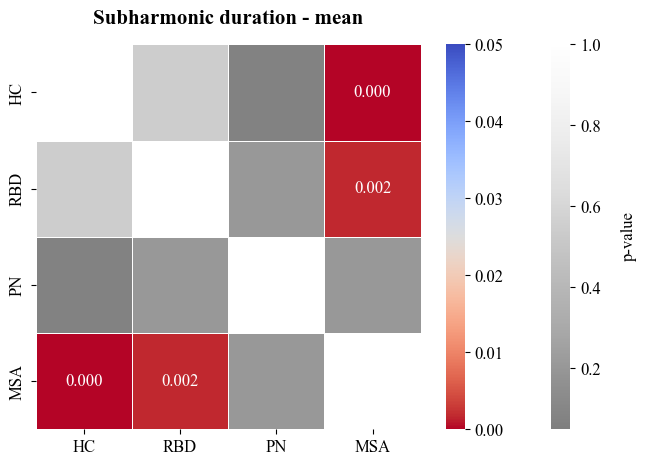


---------------------------------------------------------------
                     Subharmonic duration - median
---------------------------------------------------------------

Group medians:
group
HC     0.033333
MSA    0.045000
PN     0.043750
RBD    0.030000
Name: median_dur, dtype: float64

Group means:
group
HC     0.038336
MSA    0.068871
PN     0.060808
RBD    0.049503
Name: median_dur, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1         H     p-unc
Kruskal  group      3  17.62994  0.000524
Effect eta squared: 0.0446
Effect epsilon squared: 0.0533

Mean ranks
group
HC     144.541667
MSA    195.407407
PN     181.168675
RBD    146.089286
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.003791  0.053123  0.916423
MSA  0.003791  1.000000  0.680305  0.004605
PN   0.053123  0.680305  1.000000  0.053144
RBD  0.916423  0.004605  0.053144  1.000000
       

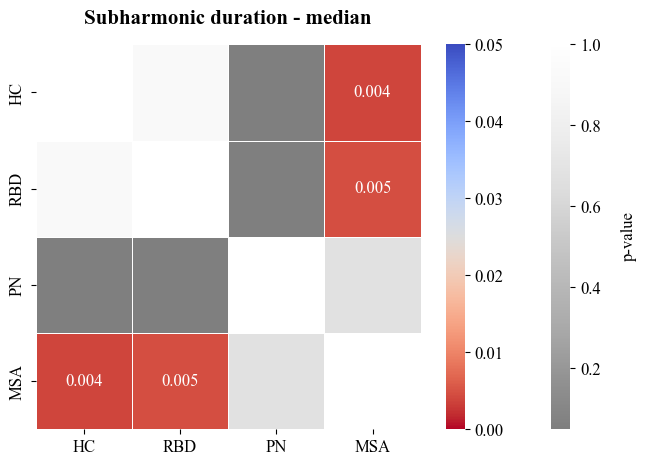


---------------------------------------------------------------
                     Subharmonic duration - standard deviation
---------------------------------------------------------------

Group medians:
group
HC     0.026586
MSA    0.113997
PN     0.055897
RBD    0.068426
Name: std_dur, dtype: float64

Group means:
group
HC     0.056050
MSA    0.144728
PN     0.104113
RBD    0.106535
Name: std_dur, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1          H     p-unc
Kruskal  group      3  20.628728  0.000126
Effect eta squared: 0.0812
Effect epsilon squared: 0.0938

Mean ranks
group
HC      82.572581
MSA    134.096774
PN     113.883929
RBD    115.121951
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.000043  0.039507  0.045769
MSA  0.000043  1.000000  0.259186  0.280839
PN   0.039507  0.259186  1.000000  0.924951
RBD  0.045769  0.280839  0.924951  1.00

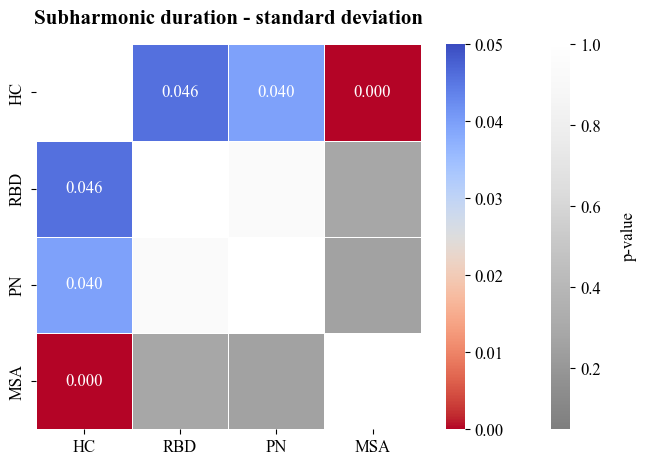


---------------------------------------------------------------
                     Subharmonic duration - CoV
---------------------------------------------------------------

Group medians:
group
HC     0.625625
MSA    0.986782
PN     0.860677
RBD    0.787296
Name: CV_dur, dtype: float64

Group means:
group
HC     0.725590
MSA    0.971327
PN     0.874932
RBD    0.883321
Name: CV_dur, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1         H     p-unc
Kruskal  group      3  9.557353  0.022729
Effect eta squared: 0.0302
Effect epsilon squared: 0.0434

Mean ranks
group
HC      91.782258
MSA    126.935484
PN     112.883929
RBD    113.390244
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.013236  0.367167  0.372756
MSA  0.013236  1.000000  0.699735  0.699735
PN   0.367167  0.699735  1.000000  0.969269
RBD  0.372756  0.699735  0.969269  1.000000
           HC     

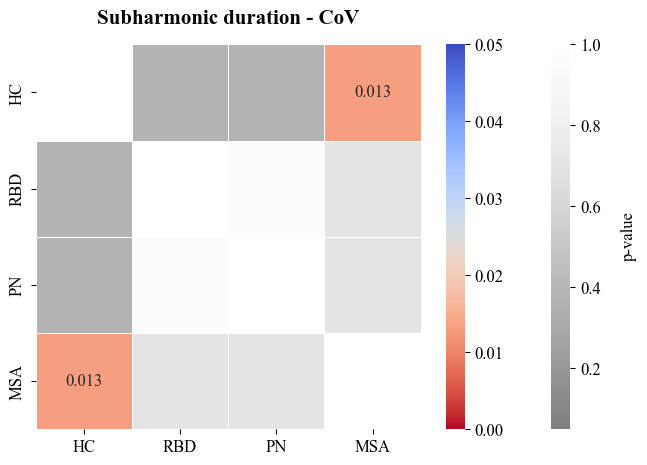


---------------------------------------------------------------
                     Subharmonic duration - the longest
---------------------------------------------------------------

Group medians:
group
HC     0.060000
MSA    0.160714
PN     0.075000
RBD    0.047500
Name: longest_dur, dtype: float64

Group means:
group
HC     0.106168
MSA    0.347894
PN     0.188623
RBD    0.159851
Name: longest_dur, dtype: float64

NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<
NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<
        Source  ddof1          H     p-unc
Kruskal  group      3  23.130435  0.000038
Effect eta squared: 0.0614
Effect epsilon squared: 0.0699

Mean ranks
group
HC     145.529762
MSA    206.901235
PN     170.614458
RBD    144.446429
Name: rank, dtype: float64

TIME FOR DUNN POST-HOC TEST
           HC       MSA        PN       RBD
HC   1.000000  0.000188  0.230903  0.941458
MSA  0.000188  1.000000  0.060368  0.000164
PN   0.230903  0.060368  1.000000  0.230903
RBD  0.941458  0.000164  0.230903  1.0

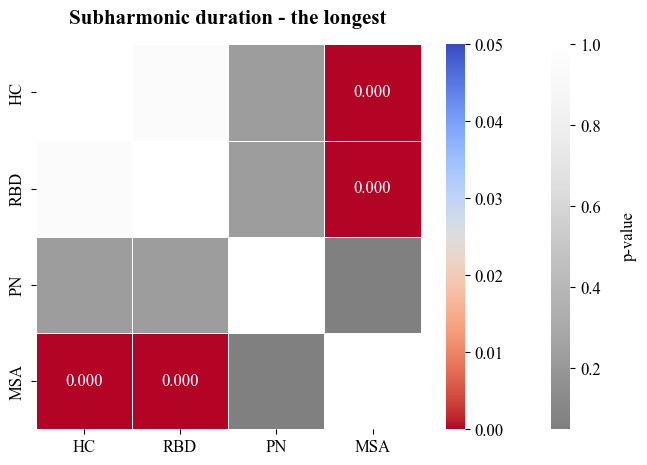

In [17]:
# ZAHRADNIK STATS

posthoc_counter = 0
posthoc_results = []

for i, (dv, label) in enumerate(variables.items()):
    print("---------------------------------------------------------------")
    print(f"                     {label}")
    print("---------------------------------------------------------------")

    df_clean = df_results_zahradnik.dropna(subset=[dv]).copy()

    # group_medians = df_clean[df_clean[dv] != 0].groupby("group")[dv].median()
    group_medians = df_clean.groupby("group")[dv].median()
    print("\nGroup medians:")
    print(group_medians)

    group_means = df_clean.groupby("group")[dv].mean()
    print("\nGroup means:")
    print(group_means)
    print()

    # Shapiro-Wilk normality test
    norm_results = pg.normality(data=df_clean, dv=dv, group="group") # -> norm_results.normal
    if norm_results.normal.all():
        print("NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<")
    else:
        print("NON-NORMAL <<<<<<<<<<<<<<<<<<<<<<<<<")

    # Levene homoscedasticity test
    homo_results = pg.homoscedasticity(data=df_clean, dv=dv, group="group") # -> homo_results.equal_var
    if homo_results.equal_var.iloc[0]:
        print("HOMO <<<<<<<<<<<<<<<<<<<<<<<<<")
    else:
        print("NON-HOMO <<<<<<<<<<<<<<<<<<<<<<<<<")

    # KRUSKAL-WALLIS GROUP COMPARISON
    kw = pg.kruskal(data=df_clean, dv=dv, between="group")
    print(kw)
    H = kw["H"].values[0]
    k = len(groups)
    n = len(df_clean)
    eta_sq = (H-k+1)/(n-k)
    eps_sq = H/(n-1)
    print(f"Effect eta squared: {eta_sq:.4f}")
    print(f"Effect epsilon squared: {eps_sq:.4f}")

    print("\nMean ranks")
    df_clean["rank"] = df_clean[dv].rank()
    mean_ranks = df_clean.groupby("group")["rank"].mean()
    print(mean_ranks)

    pval = kw["p-unc"].values[0]
    # POST-HOC TEST
    if pval <= 0.05:
        posthoc_counter += 1
        print()
        print("TIME FOR DUNN POST-HOC TEST")
        dunn = sp.posthoc_dunn(df_clean, val_col=dv, group_col="group", p_adjust="holm")
        print(dunn)
        dunn = dunn.loc[groups, groups]
        print(dunn)
        reject = (dunn < 0.05)

        posthoc_results.append({"counter": posthoc_counter, "label": label, "dunn": dunn.copy()})

        n_ticks = 6
        ticks_grey = np.round(np.linspace(0.05, 1.0, n_ticks), 1)   # 1.0 → 0.05
        ticks_color = np.linspace(0.0, 0.05, n_ticks)

        plt.figure(figsize=(8, 5))
        sns.heatmap(dunn, mask=reject, fmt=".3f", cmap='Greys_r', cbar=True, linewidths=0.5, alpha = 0.5, cbar_kws={"label": "p-value", "ticks": ticks_grey}, square=True, vmin=0.05, vmax=1.0)
        sns.heatmap(dunn, mask=~reject, fmt=".3f", cmap='coolwarm_r', cbar=True, linewidths=0.5, annot=True, annot_kws={"size": 12}, square=True, vmin=0.0, vmax=0.05, cbar_kws={"ticks": ticks_color})
        cbar = plt.gca().collections[0].colorbar
        cbar.set_label("p-value", labelpad=15)
        plt.title(f"{label}", fontsize=15, pad=15, fontweight="bold")
        plt.savefig(f"posthoc/zahradnik/{label}_posthoc.png", dpi=300)
        plt.show()
    
    print()

In [10]:
# # #subharm_intervals[sample] = [group, intervals]
# # subharms_zahradnik = {}
# # subharms_zahradnik = {"MSA10": ["MSA", "monolog", [(1, 2), (3, 7), (9, 11)]], "PN503a": ["PN", "zahradnik", [(1, 2), (3, 4)]]}

# # result_rows = []

# # for sample in subharm_intervals:
# #     group = subharm_intervals[sample][0]
    
# #     record_type = subharm_intervals[sample][1]
# #     recording_path = group + "/" + record_type + "/" + sample + ".wav"
# #     print(recording_path)
# #     sample_rate, data = wavfile.read(recording_path)
    
# #     subharms = np.asarray(subharm_intervals[sample][2], dtype=float)
# #     for subharm in subharms:
# #         print(subharm)

# #     # ABSOLUTE NUMBER OF SUBHARMONICS IN THE SIGNAL
# #     subharm_total_no = len(subharms)
# #     print(f"TOTAL NO. OF SUBHARMONICS: {subharm_total_no}")

# #     # SUBHARMONICS DURATION : SIGNAL DURATION RATIO
# #     subharm_ratio, subharm_per_second, subharm_durations, density_slope, pct_subharm_num_second_half, dur_density_slope, pct_subharm_dur_second_half = subharmRatio(subharm_total_no, subharms, data, sample_rate)
# #     print(f"SUBHARMONICS-SIGNAL RATIO: {subharm_ratio}")

# #     subharm_durations = np.asarray(subharm_durations, dtype=float)

# #     # FIRST SUBHARMONIC OCCURENCE
# #     first_subharm_occur = firstSubharmOccur(subharm_total_no, subharms, data, sample_rate)
# #     print(f"SUBHARMONIC FIRST OCCURENCE: {first_subharm_occur} seconds")

# #     # SUBHARMONIC DURATION STATS
# #     avg_subharm_dur, median_subharm_dur, std_subharm_dur, coeffOfVar_subharm_dur, longest_subharm_dur = statsSubharmDur(subharm_total_no, subharm_durations)
# #     print(f"AVERAGE SUBHARMONIC DURATION: {avg_subharm_dur} seconds")    

# #     # INTER-SUBHARMONIC INTERVALS      
# #     mean_intervals, median_intervals, std_intervals, COV_intervals = interSubharmIntervals(subharm_total_no, subharms)
# #     print(mean_intervals, median_intervals, std_intervals, COV_intervals)

# #     result_rows.append(
# #                     (sample, group,
# #                     subharm_total_no, 
# #                     subharm_ratio, subharm_per_second,
# #                     density_slope, pct_subharm_num_second_half, dur_density_slope, pct_subharm_dur_second_half,
# #                     first_subharm_occur, 
# #                     avg_subharm_dur, median_subharm_dur, std_subharm_dur, coeffOfVar_subharm_dur, longest_subharm_dur,
# #                     mean_intervals, median_intervals, std_intervals, COV_intervals))

# # df_results = pd.DataFrame(
# #     result_rows,
# #     columns=["sample", "group", "subharm_num", "subharm_sig_ratio", "subharm_per_second",
# #     "density_num_slope", "pct_subharm_num_2nd_half", "density_dur_slope", "pct_subharm_dur_2nd_half",
# #     "first_occur", 
# #     "avg_dur", "median_dur", "std_dur", "CV_dur", "longest_dur",
# #     "mean_inter_intervals", "median_inter_intervals", "std_inter_intervals", "COV_inter_intervals"])

# # df_results.to_csv("cont_speech_features.csv", index=False)


# data = np.loadtxt("praat_pitches/zahradnik/HC/Pitch HC890b.txt", delimiter="\t")

# times = data[:, 0]
# pitch = data[:, 1]

# time_step = np.round(np.median(np.diff(times)), 4)
# print(f"Time step: {time_step}")

# nan_indeces = np.where(~np.isfinite(pitch))[0] # silent intervals
# print(len(nan_indeces))

# #pitch = interpolate_pitch(pitch)
# # plt.figure()
# # plt.plot(times, pitch)
# # plt.show()

# pitch_preprocessed = interpolate_short_nan_runs(pitch, time_step, max_nan_dur=0.2)
# print(len(pitch_preprocessed))
# # plt.figure()
# # plt.plot(times, pitch_preprocessed)
# # plt.show()

# if len(times) != len(pitch_preprocessed):
#     raise IndexError("Time indeces don't match pitch values!")

# win_len = 0.25 # 250 ms
# n_side = int(round((win_len / 2) / time_step))
# first_frame_idx = n_side # frame_idx = np.searchsorted(times, times[0] + win_len/2)
# last_frame_idx = len(pitch_preprocessed) - n_side -1
# fref_mode = "upper_70_90_median"
# # win_size = 2*n_side + 1

# # TODO: WINDOW HAS TO BE ONLY VALUES FOR A VALID X_T ?
# # TODO: MAYBE SMOOTH MORE THE POSTERIORS ?
# x_frames = getXtFrames(pitch_preprocessed, first_frame_idx, last_frame_idx, n_side, fref_mode)

# time_frames = times[first_frame_idx:last_frame_idx+1]
# valid_mask = np.isfinite(x_frames)
# print(x_frames[valid_mask])

# prior_non_init, prior_sub_init = 0.9, 0.1
# em = em_two_fixed_means(x_frames[valid_mask], prior_non_init, prior_sub_init)   
# posterior_sub_full = np.zeros(len(x_frames), dtype=float)
# posterior_sub_valid = em["posterior_sub"]
# posterior_sub_full[valid_mask] = posterior_sub_valid

# decision_thresh = 0.5
# # frame_preds = (posterior_sub_full >= decision_thresh)
# # print(frame_preds.sum())

# smooth_span_sec = 0.05
# smooth_win_len = int(round(smooth_span_sec / time_step))
# if smooth_win_len % 2 == 0:
#     smooth_win_len += 1
# smooth_win_len = max(smooth_win_len, 1)

# posterior_smoothed = smooth_posterior(posterior_sub_full, smooth_win_len)
# frame_preds_smoothed = (posterior_smoothed >= decision_thresh)
# print(frame_preds_smoothed.sum())


# min_subharm_dur=0.05
# min_len_frames = int(np.ceil(min_subharm_dur / time_step))
# min_gap_dur=0.2
# min_gap_frames = int(np.floor(min_gap_dur / time_step))

# frame_preds = fill_short_gaps(frame_preds_smoothed, min_gap_frames)
# print(f"After 1st gap filling: {np.sum(frame_preds)}")
# frame_preds = remove_short_subharmonic_runs(frame_preds_smoothed, min_len_frames)
# print(f"After removing short runs: {np.sum(frame_preds)}")
# frame_preds = fill_short_gaps(frame_preds_smoothed, min_gap_frames)
# print(f"After 2nd gap filling: {np.sum(frame_preds)}")

# intervals = labels_to_intervals(time_frames, frame_preds)
# print(f"Total number of subharmonic intervals: {len(intervals)}")


In [11]:
# plt.figure(figsize=(12, 6))

# plt.subplot(3, 1, 1)
# plt.plot(time_frames, x_frames)
# plt.title("x_t")
# plt.ylim([-1.1, 0.1])
# plt.grid(True)

# plt.subplot(3, 1, 2)
# plt.plot(time_frames, posterior_sub_full, label="raw posterior")
# plt.plot(time_frames, posterior_smoothed, label="smoothed posterior")
# plt.axhline(y=decision_thresh, linestyle='--', color='k', label='threshold')
# plt.title("Subharmonic posterior")
# plt.legend()
# plt.ylim([-0.1, 1.1])
# plt.grid(True)

# plt.subplot(3, 1, 3)
# plt.plot(time_frames, frame_preds.astype(int))
# plt.title("Final binary labels")
# plt.ylim([-0.1, 1.1])
# plt.grid(True)

# for s, e in intervals:
#     print(s, e)
#     plt.subplot(3, 1, 1)
#     plt.axvline(x=s, linestyle='--', color='r')
#     plt.axvline(x=e, linestyle='--', color='b')

#     plt.subplot(3, 1, 2)
#     plt.axvline(x=s, linestyle='--', color='r')
#     plt.axvline(x=e, linestyle='--', color='b')

#     plt.subplot(3, 1, 3)
#     plt.axvline(x=s, linestyle='--', color='r')
#     plt.axvline(x=e, linestyle='--', color='b')

# plt.tight_layout()
# plt.show()